In [2]:
!pip install numpy==1.26.4 pandas seaborn matplotlib 


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import sys
import os
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [4]:
# ============================================================
# LOAD SESSIONS
# ============================================================

clean_sessions_path = "../data/processed/clean"

all_clean_files = glob.glob(os.path.join(clean_sessions_path, "*.csv"))
all_clean_files.sort(key=lambda x: int(os.path.basename(x).split('_')[2]))

last_two_files = all_clean_files[-2:]

dict_sessions = {}

for file in last_two_files:
    session_id              = int(os.path.basename(file).split('_')[2])
    dict_sessions[session_id] = pd.read_csv(file, index_col='timestamp', parse_dates=True)

print(f"{len(dict_sessions)} sessions loaded")
for session_id, df in dict_sessions.items():
    print(f"  Session {session_id}: {len(df)} rows — {df.index.min()} to {df.index.max()}")

# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

output_dir_single   = "../data/augmented/single_faults"
output_dir_combined = "../data/augmented/combined_faults"
output_dir_fp       = "../data/augmented/false_positives"

os.makedirs(output_dir_single,   exist_ok=True)
os.makedirs(output_dir_combined, exist_ok=True)
os.makedirs(output_dir_fp,       exist_ok=True)

2 sessions loaded
  Session 16: 3367 rows — 2026-04-04 19:45:00 to 2026-04-07 03:51:00
  Session 17: 4415 rows — 2026-04-07 07:42:00 to 2026-04-10 09:16:00


In [5]:
""" Define thresholds and severity rules explicitly """

# ============================================================
# THRESHOLDS
# ============================================================

# TT-901 — Oil separator gas temperature
tt901_warning = 135   # 135 degC
tt901_trip    = 140      # 140 degC

# TT-902 — Discharge 1 temperature
tt902_warning = 105   # 105 degC
tt902_trip    = 110      # 110 degC

# TT-903 — Discharge 2 temperature
tt903_warning = 105   # 105 degC
tt903_trip    = 110      # 110 degC

# TT-904 — Oil temperature
tt904_warning = 90   # 90 degC
tt904_trip    = 110      # 110 degC

# PT-903 — Vacuum pressure in oil separator
pt903_warning = 0.4   # 0.4 bar
pt903_trip    = 0.5      # 0.5 bar

# ============================================================
# SEVERITY RULES
# ============================================================

small_trip_fraction  = 0.15   # 0.415
medium_trip_fraction = 0.70   # 0.470
severe_trip_fraction = 1.00   # 0.600 — claramente acima do trip

def compute_target(baseline_mean, warning, trip, severity):
    if severity == "small":
        return warning + small_trip_fraction * (trip - warning)
    if severity == "medium":
        return warning + medium_trip_fraction * (trip - warning)
    return trip + severe_trip_fraction * (trip - warning)  # severe

print("Thresholds and severity rules defined")
print(f"\nSmall target:  warning + {small_trip_fraction:.2f} * (trip - warning)")
print(f"Medium target: warning + {medium_trip_fraction:.2f} * (trip - warning)")
print(f"Severe target: trip + {severe_trip_fraction:.2f} * (trip - warning)")

Thresholds and severity rules defined

Small target:  warning + 0.15 * (trip - warning)
Medium target: warning + 0.70 * (trip - warning)
Severe target: trip + 1.00 * (trip - warning)


Session 16 — F1 small — window: 1010 to 1370 (360 rows)
Session 16 — F1 small — baseline mean: 0.0744, baseline std: 0.0697
Session 16 — F1 small — target: 0.4150, delta magnitude: 0.3406
Session 16 — F1 small — correlated sensors (|r| >= 0.7): ['PT-901', 'PT-902', 'PT-903', 'FT-901', 'VSD-901_CORRENT', 'VSD-901_POWER']
Session 16 — F1 small — anomaly rows: 360, normal rows: 3007
Session 16 — F1 small — level 1: 360, level 2: 0

Saved ../data/augmented/single_faults/session_16_F1_small.csv

Session 16 — F1 medium — window: 1515 to 2115 (600 rows)
Session 16 — F1 medium — baseline mean: 0.0800, baseline std: 0.0713
Session 16 — F1 medium — target: 0.4700, delta magnitude: 0.3900
Session 16 — F1 medium — correlated sensors (|r| >= 0.7): ['PT-901', 'PT-902', 'PT-903', 'FT-901', 'VSD-901_CORRENT', 'VSD-901_POWER']
Session 16 — F1 medium — anomaly rows: 600, normal rows: 2767
Session 16 — F1 medium — level 1: 15, level 2: 0

Saved ../data/augmented/single_faults/session_16_F1_medium.csv

Se

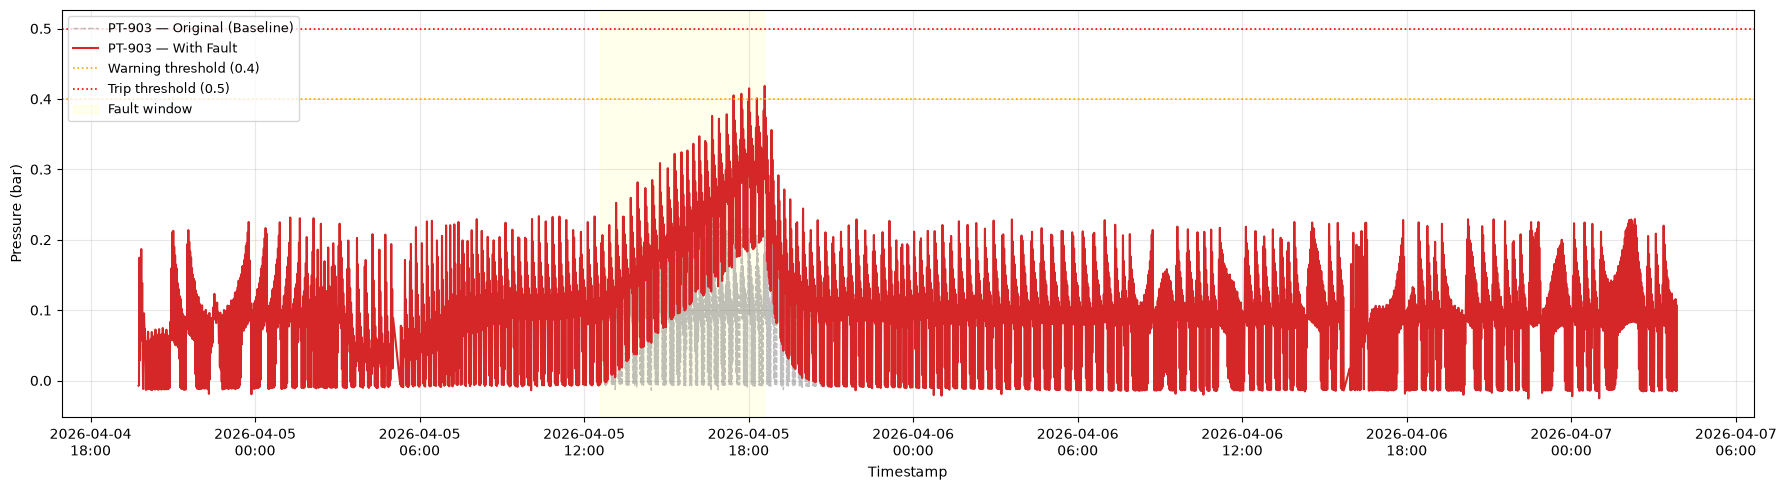

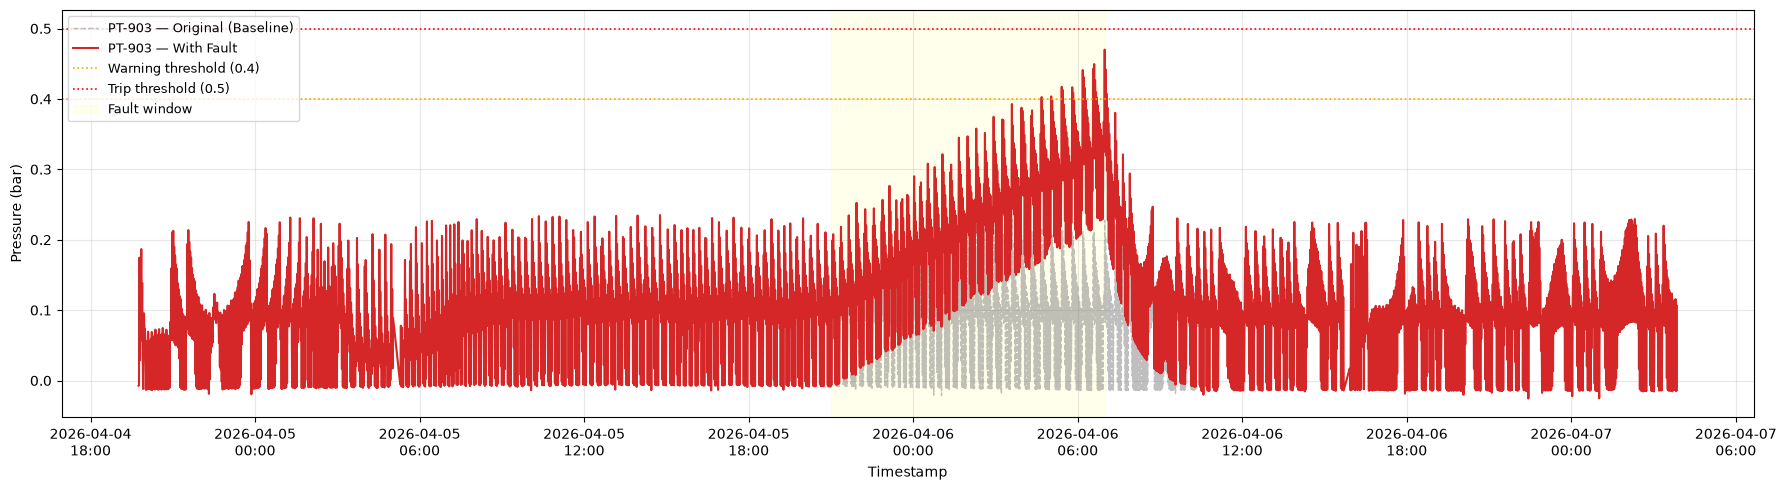

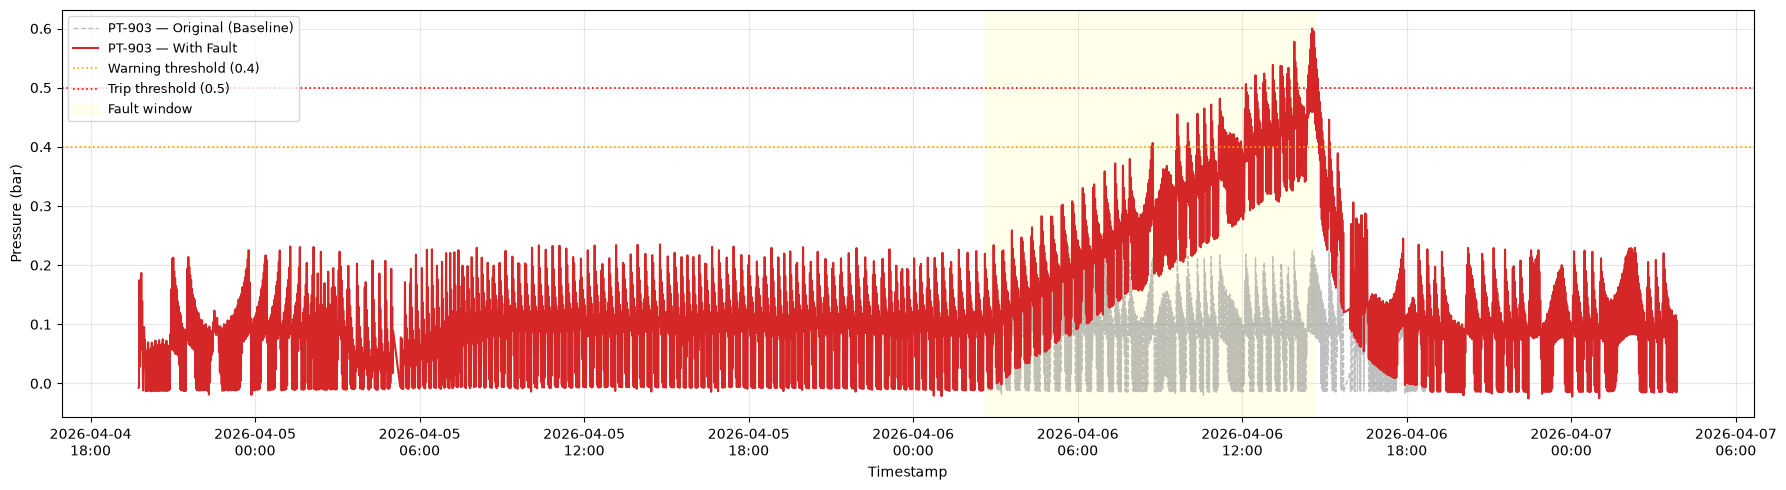

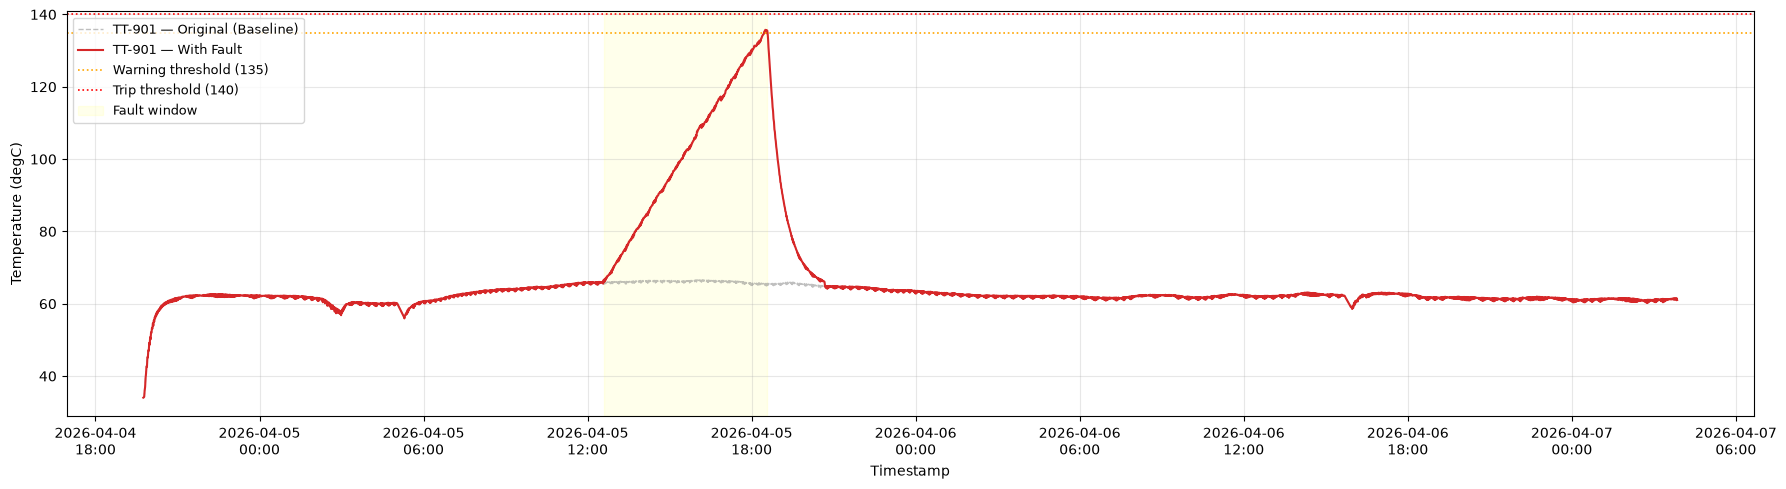

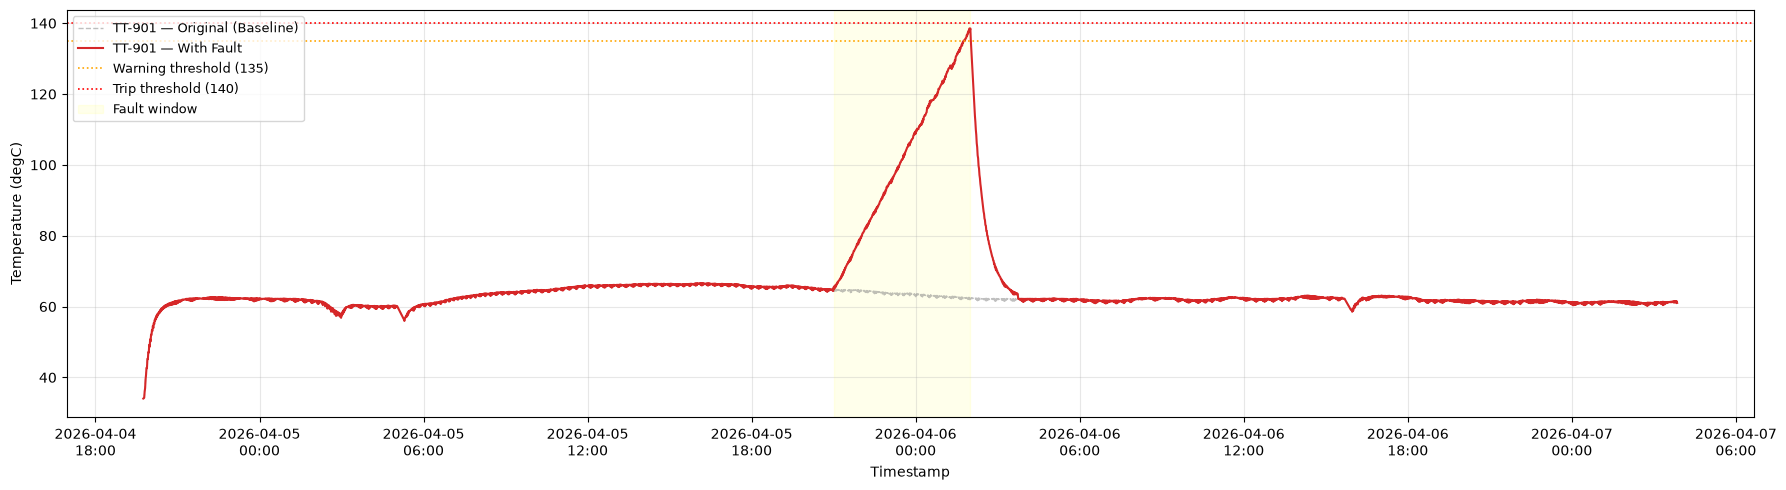

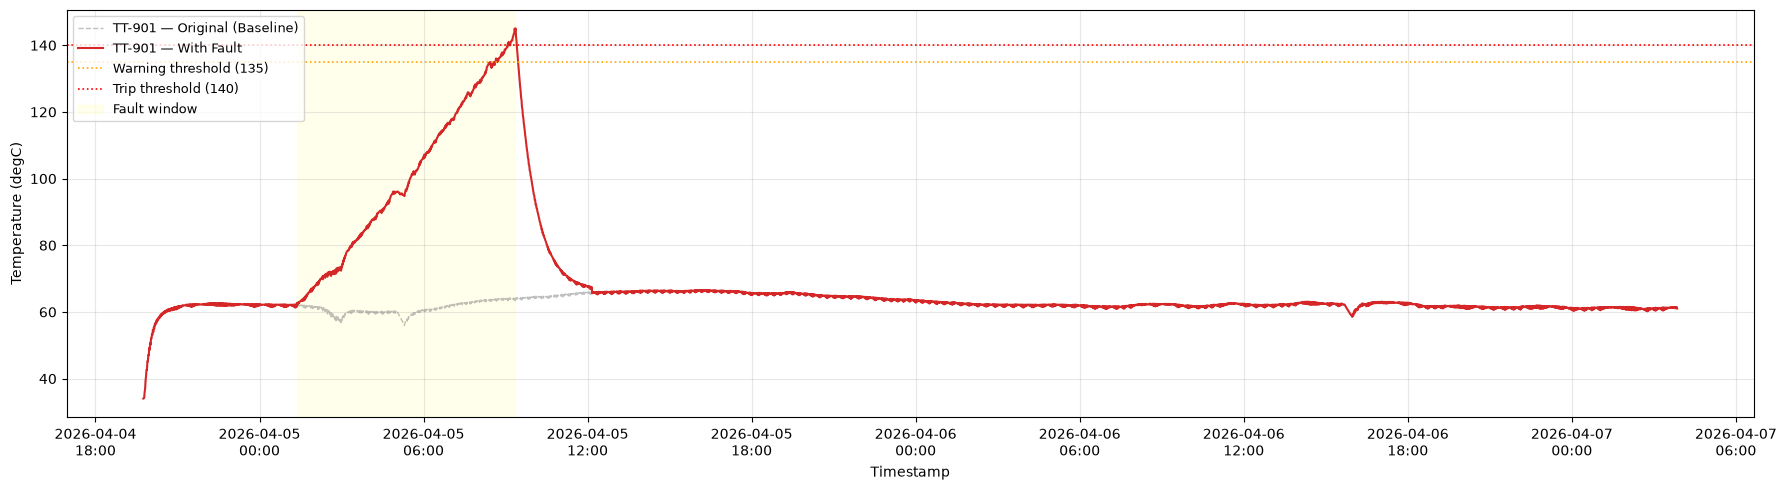

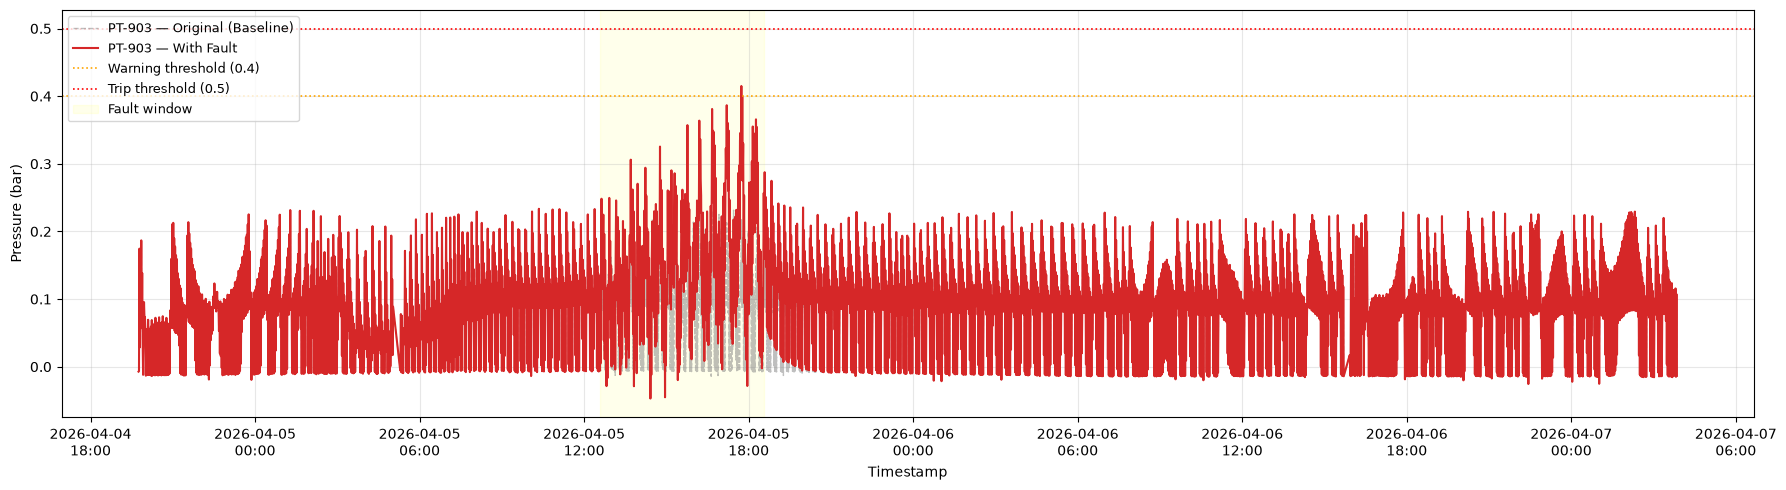

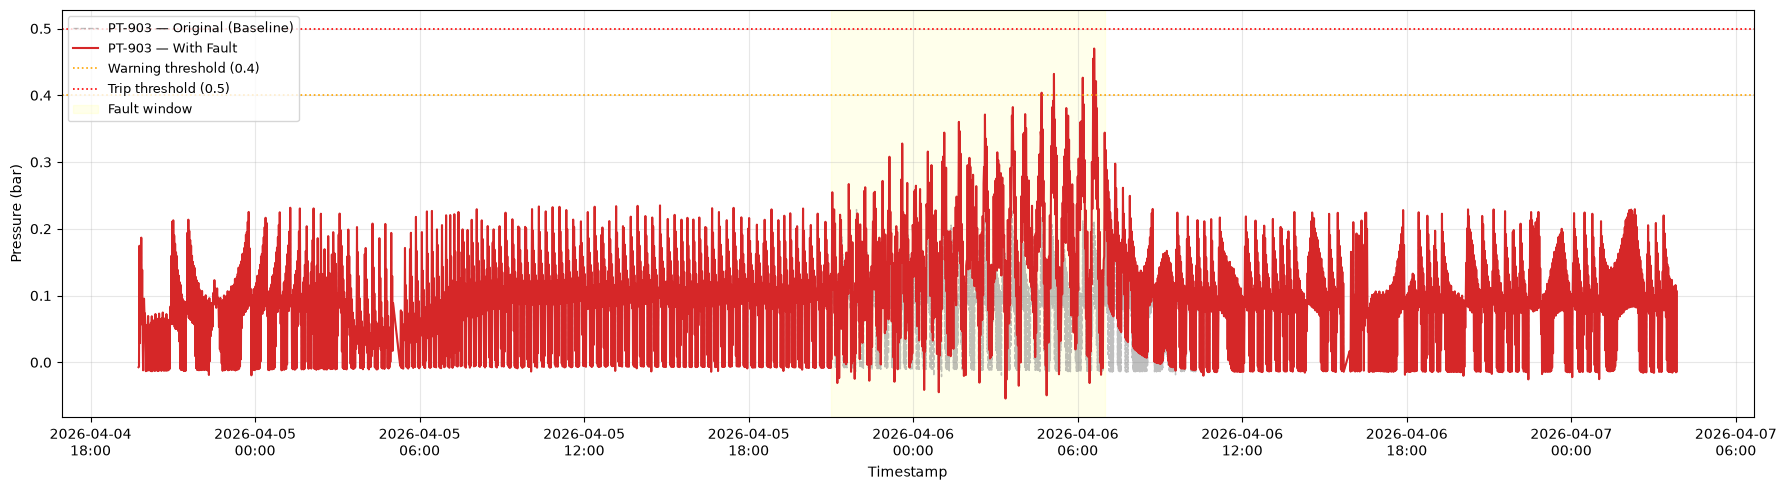

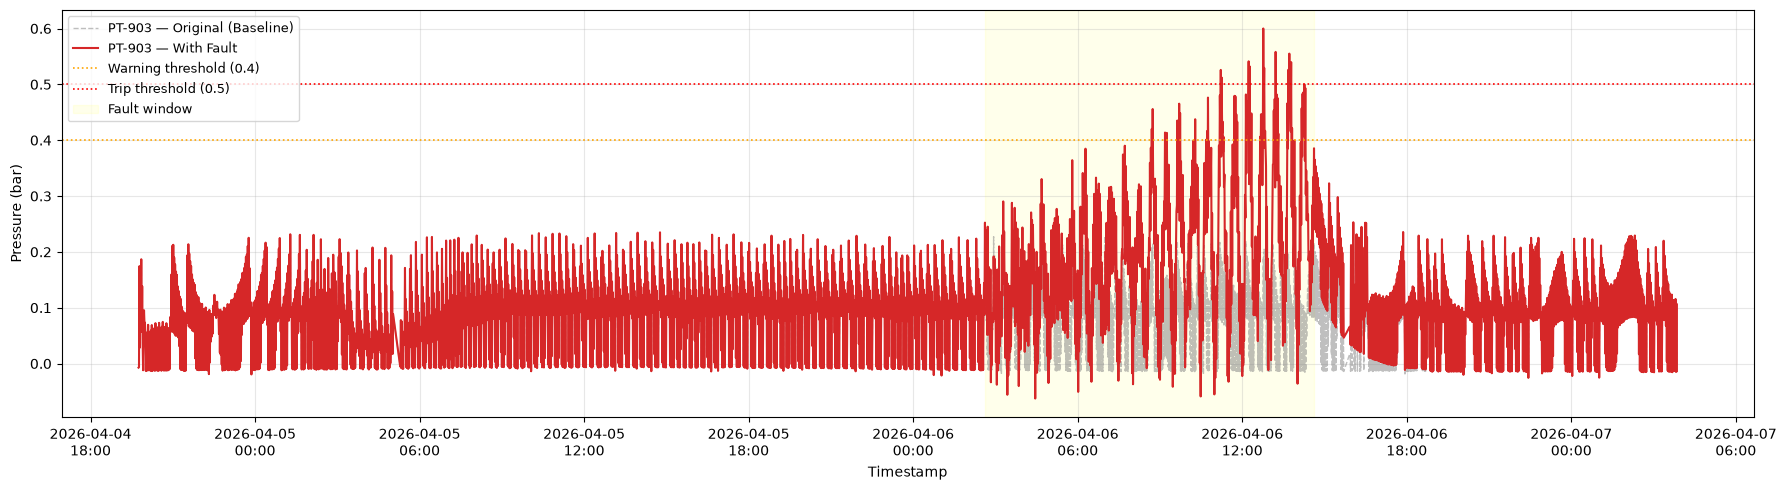

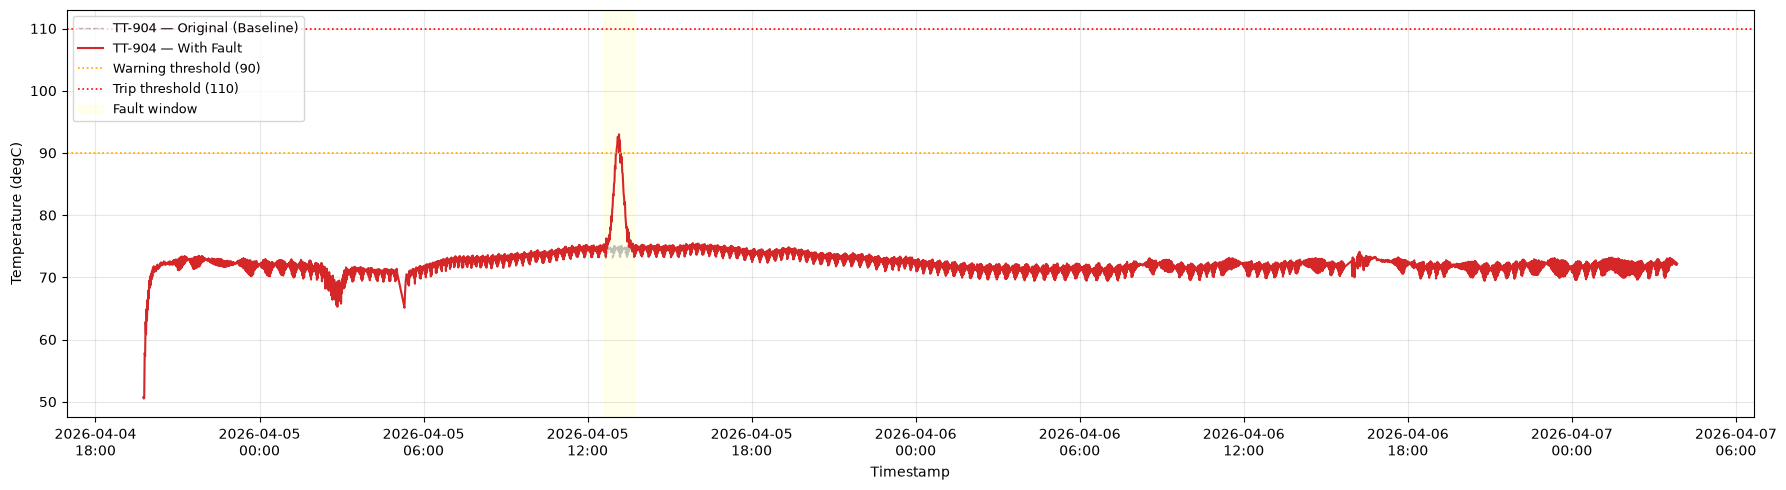

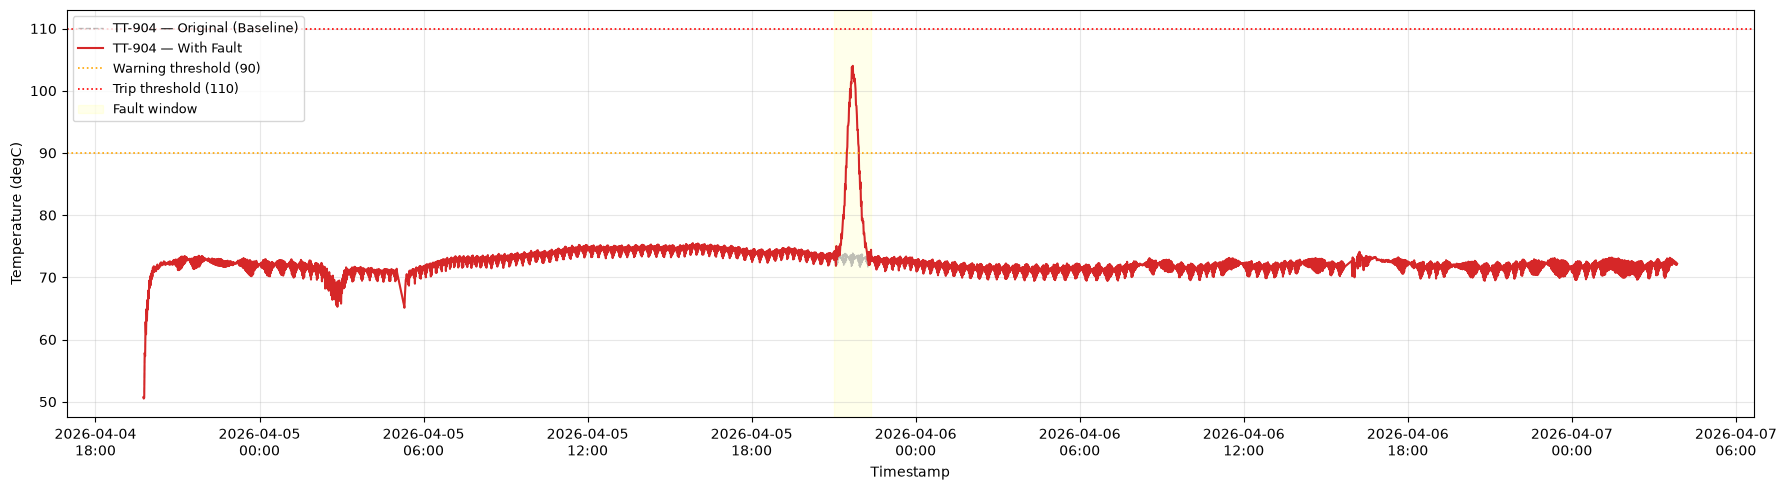

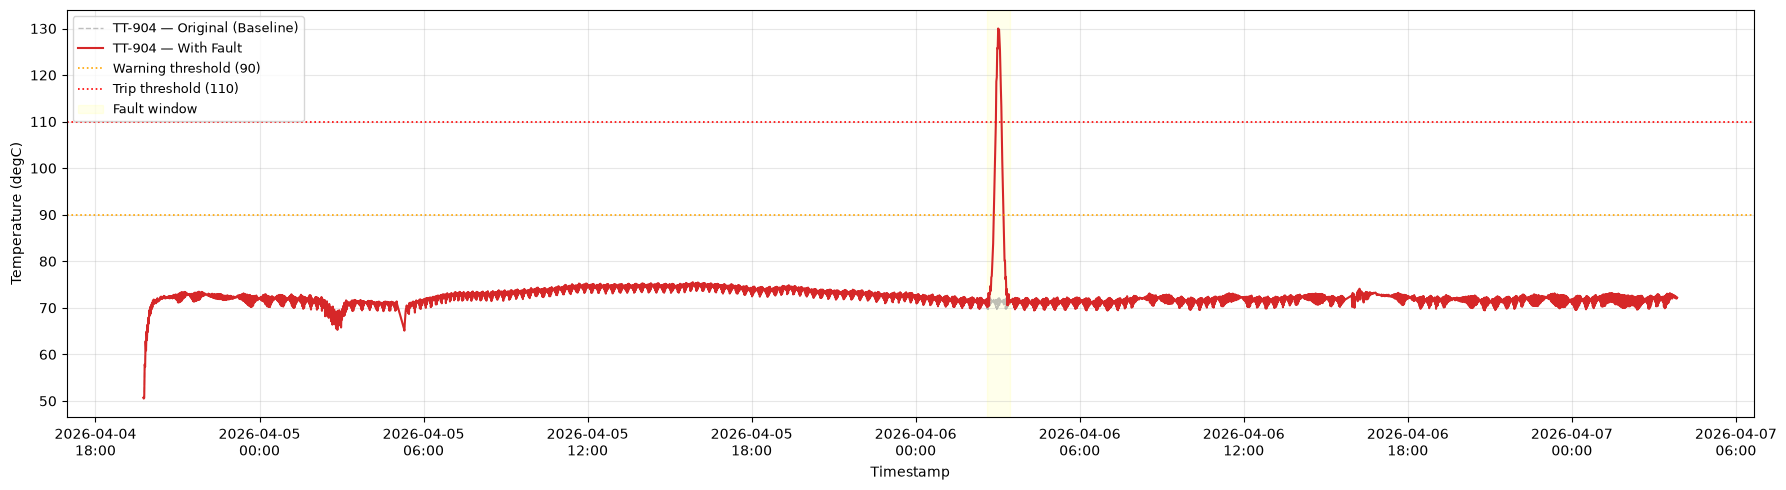

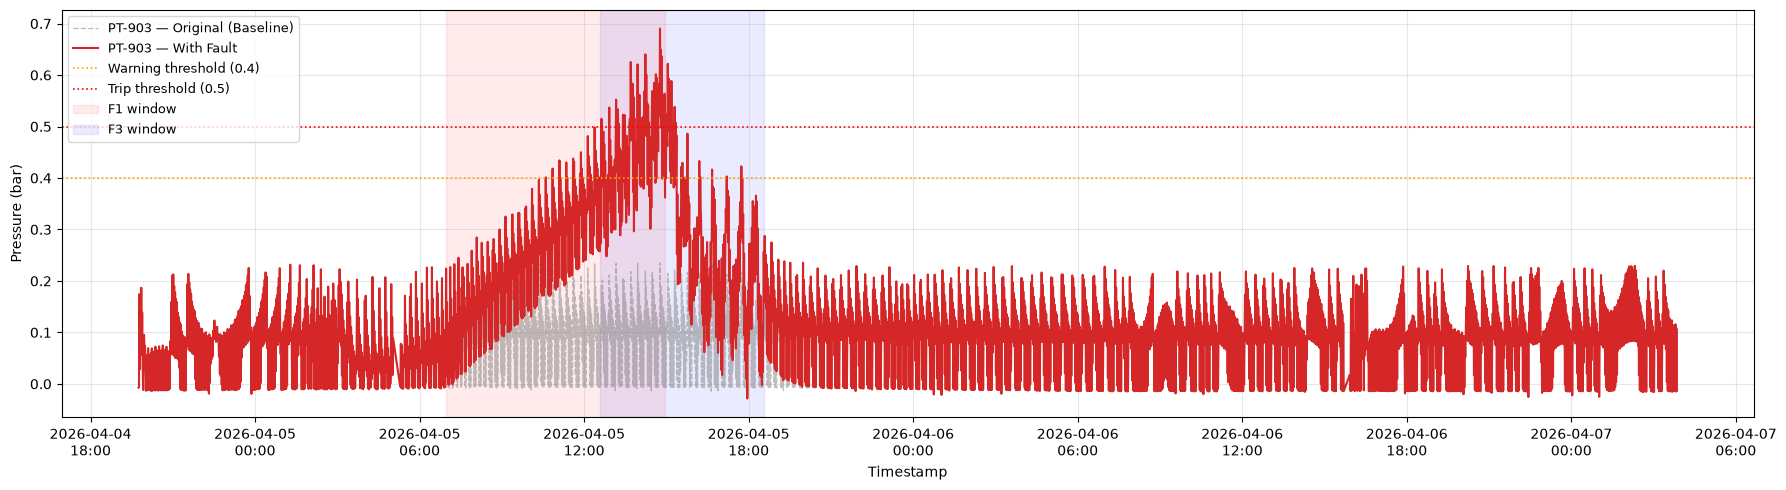

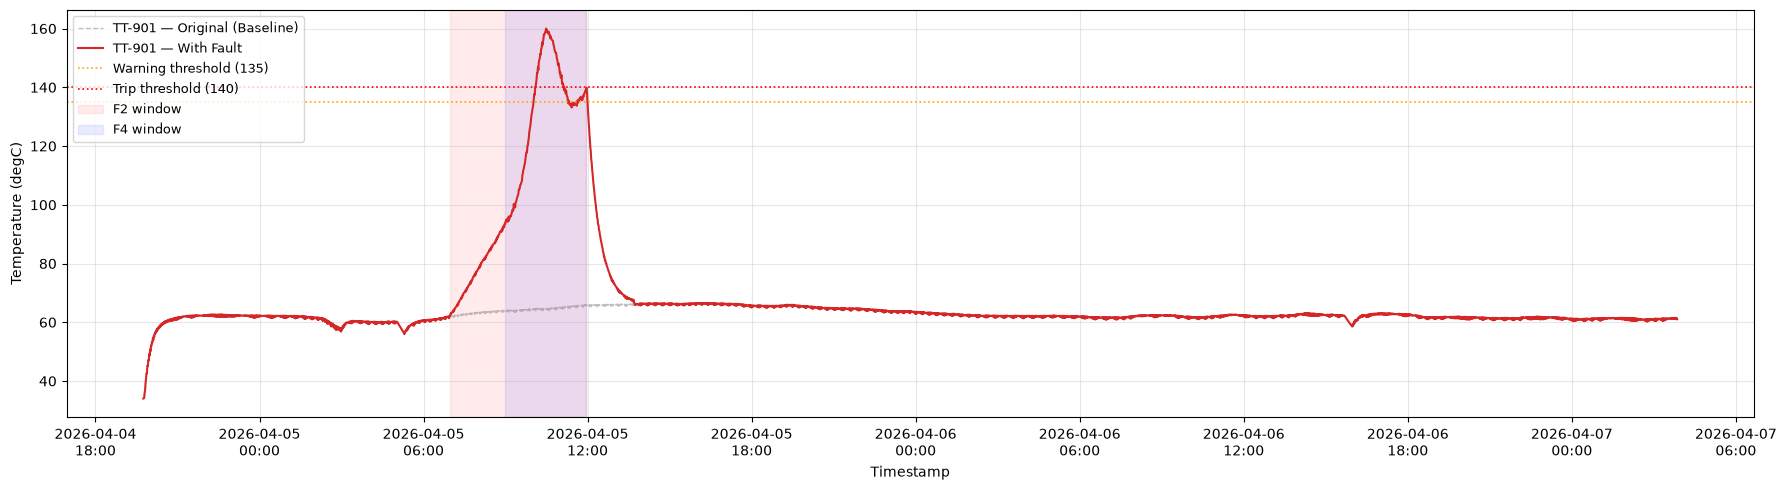

In [7]:
""" ============================================================
    GENERIC FAULT INJECTION FRAMEWORK
    Generates all single faults, combined faults, and the
    standalone false positive scenario, for every session.
    ============================================================ """

# ------------------------------------------------------------
# PHYSICAL SENSOR COLUMNS ONLY
# ------------------------------------------------------------
FEATURES = [
    "PT-901", "PT-902", "PT-903", "TT-901", "TT-902", "TT-903", "TT-904",
    "FT-201", "FT-801", "FT-901",
    "VSD-901_CORRENT", "VSD-901_POWER", "VSD-901_RPM", "VSD-901_SPEED",
]

# ------------------------------------------------------------
# THRESHOLDS (unchanged)
# ------------------------------------------------------------
THRESHOLDS = {
    "PT-903": (pt903_warning, pt903_trip),
    "TT-901": (tt901_warning, tt901_trip),
    "TT-902": (tt902_warning, tt902_trip),
    "TT-903": (tt903_warning, tt903_trip),
    "TT-904": (tt904_warning, tt904_trip),
}

# ------------------------------------------------------------
# SEVERITY TARGET AND SCORE
# ------------------------------------------------------------
SEVERITY_SCORE = {"small": 0.33, "medium": 0.67, "severe": 1.0}

# ------------------------------------------------------------
# PROPAGATION SCALE — uniform across all faults
# ------------------------------------------------------------
PROPAGATION_SCALE = 0.9

# ------------------------------------------------------------
# DELTA SHAPES — uniform profile across all severities
# ------------------------------------------------------------
def generate_ramp_delta(total_l, delta_mag, baseline_std):
    trend = np.linspace(0, delta_mag, total_l)
    noise_start = min(baseline_std * 0.10, abs(delta_mag) * 0.05)
    noise_end   = min(baseline_std * 0.50, abs(delta_mag) * 0.15)
    noise_scale = np.linspace(noise_start, noise_end, total_l)
    noise = np.random.normal(0, noise_scale, total_l)
    raw = trend + noise
    return pd.Series(raw).rolling(10, center=True, min_periods=1).mean().values

def generate_oscillation_delta(total_l, delta_mag, baseline_std):
    # (1 + sin) / 2 keeps the delta always >= 0, so the sensor never
    # dips below baseline — physically correct and visually clean
    t = np.arange(total_l)
    period = 30
    envelope = np.linspace(0.1, 1.0, total_l)
    noise_std = min(baseline_std * 0.50, abs(delta_mag) * 0.15)
    noise = np.random.normal(0, noise_std, total_l)
    return delta_mag * (1 + np.sin(2 * np.pi * t / period)) / 2 * envelope + noise

def generate_spike_delta(total_l, delta_mag, baseline_std):
    t = np.arange(total_l)
    # wider width (0.15 instead of 0.08) avoids the needle effect on short windows
    center, width = int(total_l * 0.5), max(int(total_l * 0.15), 1)
    noise_std = min(baseline_std * 0.30, abs(delta_mag) * 0.10)
    noise = np.random.normal(0, noise_std, total_l)
    return delta_mag * np.exp(-0.5 * ((t - center) / width) ** 2) + noise

SHAPE_GENERATORS = {
    "ramp": generate_ramp_delta,
    "oscillation": generate_oscillation_delta,
    "spike": generate_spike_delta,
}
CLIP_FLOOR = {"ramp": True, "oscillation": False, "spike": True}

# ------------------------------------------------------------
# TARGET ALIGNMENT — single scalar rescale, no per-row clipping
# ------------------------------------------------------------
def align_to_target(delta, active_values, target, clip_floor):
    """Scale the whole delta by ONE factor so that the peak of the injected
    signal lands exactly on target. Because it is a single scalar, the shape
    and the natural oscillation of the sensor are preserved — no flat top."""
    if clip_floor:
        delta = np.maximum(delta, 0)
    if delta.max() <= 0:
        return delta

    lo, hi = 0.0, 1.0
    while np.max(active_values + hi * delta) < target and hi < 1e6:
        hi *= 2.0
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if np.max(active_values + mid * delta) < target:
            lo = mid
        else:
            hi = mid
    delta = 0.5 * (lo + hi) * delta

    if clip_floor:
        delta = np.maximum(delta, 0)
    return delta

# ------------------------------------------------------------
# DECAY — bounded in time, fades fully back to baseline
# ------------------------------------------------------------
DECAY_LENGTH_RATIO = 0.35   # decay spans 35% of the fault window
DECAY_RATE_VALUE   = 4.0    # exp(-4) ~ 0.018 -> effectively back to baseline

# ------------------------------------------------------------
# PROPAGATION TO CORRELATED SENSORS
# ------------------------------------------------------------
def inject_and_propagate(df, delta, start_idx, end_idx, main_sensor, corr, corr_sensors):
    for sensor in corr_sensors:
        if sensor in df.columns:
            scale = 1.0 if sensor == main_sensor else PROPAGATION_SCALE
            df.iloc[start_idx:end_idx, df.columns.get_loc(sensor)] += delta * corr[sensor] * scale
    return df

# ------------------------------------------------------------
# SINGLE FAULT INJECTION
# ------------------------------------------------------------
DECAY_RATE = {"small": 1.2, "medium": 0.3, "severe": 0.3}

def inject_single_fault(df_orig, sensor, warning, trip, severity, length_hours, start_from,
                         corr_threshold, shape, anomaly_type, label):
    np.random.seed(42)
    session_length = len(df_orig)
    start_idx = int(round(session_length * start_from))
    end_idx = min(start_idx + int(round(length_hours * 60)), session_length)
    total_l = end_idx - start_idx

    clean_mask = df_orig["pt903_frozen_flag"] == 0
    pre_fault_clean = clean_mask.iloc[:start_idx]
    baseline_mean = df_orig[sensor].iloc[:start_idx][pre_fault_clean].mean()
    baseline_std  = df_orig[sensor].iloc[:start_idx][pre_fault_clean].std()

    target = compute_target(baseline_mean, warning, trip, severity)
    delta_mag = target - baseline_mean

    delta = SHAPE_GENERATORS[shape](total_l, delta_mag, baseline_std)
    active_values = df_orig[sensor].iloc[start_idx:end_idx].to_numpy()
    delta = align_to_target(delta, active_values, target, CLIP_FLOOR[shape])

    corr = df_orig.loc[clean_mask, FEATURES].corr(method="pearson", numeric_only=True)[sensor]
    corr_sensors = corr[abs(corr) >= corr_threshold].index.tolist()

    df = df_orig.copy()
    df = inject_and_propagate(df, delta, start_idx, end_idx, sensor, corr, corr_sensors)

    remaining = session_length - end_idx
    if remaining > 0:
        decay_len = min(max(int(round(total_l * DECAY_LENGTH_RATIO)), 1), remaining)
        decay = delta[-1] * np.exp(-DECAY_RATE_VALUE * np.linspace(0, 1, decay_len))
        for s in corr_sensors:
            if s in df.columns:
                scale = 1.0 if s == sensor else PROPAGATION_SCALE
                df.iloc[end_idx:end_idx + decay_len, df.columns.get_loc(s)] += decay * corr[s] * scale

    df["anomaly_level"] = 0
    df["is_injected_anomaly"] = 0
    df["anomaly_type"] = "normal"
    df["severity_score"] = 0.0
    if severity == "small":
        df.iloc[start_idx:end_idx, df.columns.get_loc("anomaly_level")] = 1
    else:
        injected_values = df[sensor].iloc[start_idx:end_idx]
        labels = np.where(injected_values >= trip, 2, np.where(injected_values >= warning, 1, 0))
        df.iloc[start_idx:end_idx, df.columns.get_loc("anomaly_level")] = labels
    df.iloc[start_idx:end_idx, df.columns.get_loc("is_injected_anomaly")] = 1
    df.iloc[start_idx:end_idx, df.columns.get_loc("anomaly_type")] = anomaly_type
    df.iloc[start_idx:end_idx, df.columns.get_loc("severity_score")] = SEVERITY_SCORE[severity]

    print(f"{label} — window: {start_idx} to {end_idx} ({total_l} rows)")
    print(f"{label} — baseline mean: {baseline_mean:.4f}, baseline std: {baseline_std:.4f}")
    print(f"{label} — target: {target:.4f}, delta magnitude: {delta_mag:.4f}")
    print(f"{label} — correlated sensors (|r| >= {corr_threshold}): {corr_sensors}")
    print(f"{label} — anomaly rows: {int(df['is_injected_anomaly'].sum())}, normal rows: {int((df['is_injected_anomaly']==0).sum())}")
    print(f"{label} — level 1: {int((df['anomaly_level']==1).sum())}, level 2: {int((df['anomaly_level']==2).sum())}\n")

    return df, start_idx, end_idx

# ------------------------------------------------------------
# FAULT DEFINITIONS
# ------------------------------------------------------------
FAULT_CONFIGS = {
    "F1": dict(sensor="PT-903", corr_threshold=0.70, shape="ramp",
               anomaly_type="clogged_filters",
               severities={"small": (6, 0.30), "medium": (10, 0.45), "severe": (12, 0.55)}),
    "F2": dict(sensor="TT-901", corr_threshold=0.60, shape="ramp",
               anomaly_type="cooling_fault",
               severities={"small": (6, 0.30), "medium": (5, 0.45), "severe": (8, 0.10)}),
    "F3": dict(sensor="PT-903", corr_threshold=0.70, shape="oscillation",
               anomaly_type="valve_fault",
               severities={"small": (6, 0.30), "medium": (10, 0.45), "severe": (12, 0.55)}),
    "F4": dict(sensor="TT-904", corr_threshold=0.65, shape="spike",
               anomaly_type="bearing_fault",
               severities={"small": (1.12, 0.30), "medium": (1.4, 0.45), "severe": (0.85, 0.55)}),
}

# ------------------------------------------------------------
# GENERATE ALL SINGLE FAULTS, FOR EVERY SESSION
# ------------------------------------------------------------
single_fault_results = {}

for session_id, df_session in dict_sessions.items():
    for fault_id, cfg in FAULT_CONFIGS.items():
        warning, trip = THRESHOLDS[cfg["sensor"]]
        for severity, (length_hours, start_from) in cfg["severities"].items():
            label = f"Session {session_id} — {fault_id} {severity}"
            df_out, start_idx, end_idx = inject_single_fault(
                df_session, cfg["sensor"], warning, trip, severity,
                length_hours, start_from, cfg["corr_threshold"],
                cfg["shape"], cfg["anomaly_type"], label,
            )
            filename = f"{output_dir_single}/session_{session_id}_{fault_id}_{severity}.csv"
            df_out.to_csv(filename)
            single_fault_results[(session_id, fault_id, severity)] = (df_out, start_idx, end_idx)
            print(f"Saved {filename}\n")

# ------------------------------------------------------------
# COMBINED FAULTS
# ------------------------------------------------------------
def inject_combined_fault(df_orig, components, combo_name, output_path):
    df = df_orig.copy()
    windows = {}
    session_length = len(df_orig)
    clean_mask = df_orig["pt903_frozen_flag"] == 0

    for comp in components:
        np.random.seed(42)
        start_idx = comp.get("start_idx", int(round(session_length * comp.get("start_from", 0))))
        end_idx = min(start_idx + int(round(comp["length_hours"] * 60)), session_length)
        total_l = end_idx - start_idx

        pre_fault_clean = clean_mask.iloc[:start_idx]
        baseline_mean = df_orig[comp["sensor"]].iloc[:start_idx][pre_fault_clean].mean()
        baseline_std  = df_orig[comp["sensor"]].iloc[:start_idx][pre_fault_clean].std()
        target = compute_target(baseline_mean, comp["warning"], comp["trip"], comp["severity"])
        delta_mag = target - baseline_mean

        delta = SHAPE_GENERATORS[comp["shape"]](total_l, delta_mag, baseline_std)
        active_values = df_orig[comp["sensor"]].iloc[start_idx:end_idx].to_numpy()
        delta = align_to_target(delta, active_values, target, CLIP_FLOOR[comp["shape"]])

        corr = df_orig.loc[clean_mask, FEATURES].corr(method="pearson", numeric_only=True)[comp["sensor"]]
        corr_sensors = corr[abs(corr) >= comp["corr_threshold"]].index.tolist()
        df = inject_and_propagate(df, delta, start_idx, end_idx, comp["sensor"], corr, corr_sensors)

        remaining = session_length - end_idx
        if remaining > 0:
            decay_len = min(max(int(round(total_l * DECAY_LENGTH_RATIO)), 1), remaining)
            decay = delta[-1] * np.exp(-DECAY_RATE_VALUE * np.linspace(0, 1, decay_len))
            for s in corr_sensors:
                if s in df.columns:
                    scale = 1.0 if s == comp["sensor"] else PROPAGATION_SCALE
                    df.iloc[end_idx:end_idx + decay_len, df.columns.get_loc(s)] += decay * corr[s] * scale

        windows[comp["fault_id"]] = (start_idx, end_idx)
        print(f"{combo_name} — {comp['fault_id']} ({comp['severity']}) — window: {start_idx} to {end_idx} ({total_l} rows)")
        print(f"{combo_name} — {comp['fault_id']} — correlated sensors: {corr_sensors}")

    df["anomaly_level"] = 0
    df["is_injected_anomaly"] = 0
    df["anomaly_type"] = "normal"
    df["severity_score"] = 0.0

    active_cols = []
    for comp in components:
        col = f"{comp['fault_id']}_active"
        active_cols.append(col)
        s, e = windows[comp["fault_id"]]
        df[col] = 0
        df.iloc[s:e, df.columns.get_loc(col)] = 1
        df.iloc[s:e, df.columns.get_loc("severity_score")] = np.maximum(
            df.iloc[s:e]["severity_score"].values, SEVERITY_SCORE[comp["severity"]]
        )

    df["active_fault_count"] = df[active_cols].sum(axis=1)
    df["has_active_overlap"] = (df["active_fault_count"] >= 2).astype(int)

    injected_mask = df[active_cols].sum(axis=1) > 0
    df.loc[injected_mask, "is_injected_anomaly"] = 1
    df.loc[injected_mask, "anomaly_level"] = 1

    for comp in components:
        s, e = windows[comp["fault_id"]]
        injected_values = df[comp["sensor"]].iloc[s:e]
        labels = np.where(injected_values >= comp["trip"], 2, np.where(injected_values >= comp["warning"], 1, 0))
        df.iloc[s:e, df.columns.get_loc("anomaly_level")] = np.maximum(df.iloc[s:e]["anomaly_level"].values, labels)

    df["anomaly_type"] = "normal"
    for comp in components:
        mask = df[f"{comp['fault_id']}_active"] == 1
        df.loc[mask, "anomaly_type"] = np.where(
            df.loc[mask, "anomaly_type"] == "normal",
            comp["anomaly_type"],
            df.loc[mask, "anomaly_type"] + "+" + comp["anomaly_type"],
        )

    df.to_csv(output_path)
    print(f"\n{combo_name} saved")
    print(f"Normal rows: {(df['is_injected_anomaly']==0).sum()}, Anomaly rows: {df['is_injected_anomaly'].sum()}")
    print(f"Level 1: {(df['anomaly_level']==1).sum()}, Level 2: {(df['anomaly_level']==2).sum()}")
    print(f"Anomaly types found: {df['anomaly_type'].unique()}")
    print(f"Active overlap rows: {df['has_active_overlap'].sum()}\n")

    return df, windows

combined_fault_results = {}

for session_id, df_session in dict_sessions.items():
    session_length = len(df_session)

    combo_a_components = [
        dict(fault_id="F1", sensor="PT-903", warning=pt903_warning, trip=pt903_trip, severity="severe",
             length_hours=8, start_from=0.20, corr_threshold=0.70,
             shape="ramp", anomaly_type="clogged_filters"),
        dict(fault_id="F3", sensor="PT-903", warning=pt903_warning, trip=pt903_trip, severity="small",
             length_hours=6, start_from=0.30, corr_threshold=0.70,
             shape="oscillation", anomaly_type="valve_fault"),
    ]
    df_a, windows_a = inject_combined_fault(
        df_session, combo_a_components, f"Session {session_id} Combo A",
        f"{output_dir_combined}/session_{session_id}_combo_A_F1severe_F3small.csv",
    )
    combined_fault_results[(session_id, "combo_A")] = (df_a, windows_a)

    f2_start_idx = int(round(session_length * 0.20))
    combo_b_components = [
        dict(fault_id="F2", sensor="TT-901", warning=tt901_warning, trip=tt901_trip, severity="medium",
             length_hours=5, start_idx=f2_start_idx, corr_threshold=0.60,
             shape="ramp", anomaly_type="cooling_fault"),
        dict(fault_id="F4", sensor="TT-904", warning=tt904_warning, trip=tt904_trip, severity="severe",
             length_hours=3, start_idx=f2_start_idx + 120, corr_threshold=0.65,
             shape="spike", anomaly_type="bearing_fault"),
    ]
    df_b, windows_b = inject_combined_fault(
        df_session, combo_b_components, f"Session {session_id} Combo B",
        f"{output_dir_combined}/session_{session_id}_combo_B_F2medium_F4severe.csv",
    )
    combined_fault_results[(session_id, "combo_B")] = (df_b, windows_b)

# ------------------------------------------------------------
# STANDALONE FALSE POSITIVE
# ------------------------------------------------------------
def inject_false_positive(df_orig, sensor, warning, trip, start_from, duration_min, label, output_path):
    np.random.seed(42)
    session_length = len(df_orig)
    start_idx = int(round(session_length * start_from))
    end_idx = min(start_idx + duration_min, session_length)
    total_l = end_idx - start_idx

    clean_mask = df_orig["pt903_frozen_flag"] == 0
    pre_fp_clean = clean_mask.iloc[:start_idx]
    baseline_mean = df_orig[sensor].iloc[:start_idx][pre_fp_clean].mean()
    baseline_std  = df_orig[sensor].iloc[:start_idx][pre_fp_clean].std()

    spike_target = trip * 0.80
    delta_mag = spike_target - baseline_mean

    t = np.arange(total_l)
    center, width = int(total_l * 0.5), max(int(total_l * 0.15), 1)
    noise = np.random.normal(0, baseline_std * 0.05, total_l)
    delta = delta_mag * np.exp(-0.5 * ((t - center) / width) ** 2) + noise
    delta = np.maximum(delta, 0)

    df = df_orig.copy()
    df.iloc[start_idx:end_idx, df.columns.get_loc(sensor)] += delta

    df["anomaly_level"] = 0
    df["is_injected_anomaly"] = 0
    df["anomaly_type"] = "normal"
    df["severity_score"] = 0.0
    df.iloc[start_idx:end_idx, df.columns.get_loc("anomaly_type")] = "false_positive"

    df.to_csv(output_path)
    print(f"{label} — window: {start_idx} to {end_idx} ({total_l} rows)")
    print(f"{label} — baseline mean: {baseline_mean:.4f}, spike target: {spike_target:.4f}")
    print(f"{label} — false positive rows: {(df['anomaly_type']=='false_positive').sum()}")
    print(f"{label} — normal rows: {(df['anomaly_type']=='normal').sum()}\n")
    return df

FP_SENSOR_PER_SESSION = {16: "TT-902", 17: "TT-903"}

for session_id, df_session in dict_sessions.items():
    sensor = FP_SENSOR_PER_SESSION.get(session_id, "TT-902")
    warning, trip = THRESHOLDS[sensor]
    inject_false_positive(
        df_session, sensor, warning, trip, start_from=0.40, duration_min=12,
        label=f"Session {session_id} standalone FP ({sensor})",
        output_path=f"{output_dir_fp}/session_{session_id}_fp_standalone_{sensor.replace('-','')}.csv",
    )

# ------------------------------------------------------------
# PLOTTING — single fault
# ------------------------------------------------------------
def plot_single_fault(df_orig, df_fault, sensor, warning, trip, start_idx, end_idx, ylabel, save_path):
    fig, ax1 = plt.subplots(1, 1, figsize=(18, 5))
    fault_start_ts = df_fault.index[start_idx]
    fault_end_ts   = df_fault.index[end_idx - 1]

    ax1.plot(df_orig.index, df_orig[sensor], color="gray", alpha=0.5, linestyle="--", linewidth=1.0,
             label=f"{sensor} — Original (Baseline)")
    ax1.plot(df_fault.index, df_fault[sensor], color="#d62728", linewidth=1.5, label=f"{sensor} — With Fault")
    ax1.axhline(y=warning, color="orange", linestyle=":", linewidth=1.2, label=f"Warning threshold ({warning})")
    ax1.axhline(y=trip, color="red", linestyle=":", linewidth=1.2, label=f"Trip threshold ({trip})")
    ax1.axvspan(fault_start_ts, fault_end_ts, color="yellow", alpha=0.08, label="Fault window")

    ax1.set_ylabel(ylabel)
    ax1.set_xlabel("Timestamp")
    ax1.legend(loc="upper left", fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

YLABELS = {
    "PT-903": "Pressure (bar)",
    "TT-901": "Temperature (degC)",
    "TT-902": "Temperature (degC)",
    "TT-903": "Temperature (degC)",
    "TT-904": "Temperature (degC)",
}

# session 16 — all faults, all severities
for fault_id in ["F1", "F2", "F3", "F4"]:
    cfg = FAULT_CONFIGS[fault_id]
    warning, trip = THRESHOLDS[cfg["sensor"]]
    for severity in ["small", "medium", "severe"]:
        df_out, start_idx, end_idx = single_fault_results[(16, fault_id, severity)]
        plot_single_fault(
            dict_sessions[16], df_out, cfg["sensor"], warning, trip, start_idx, end_idx,
            YLABELS[cfg["sensor"]], f"fault_{fault_id.lower()}_{severity}_s16.png",
        )

# ------------------------------------------------------------
# PLOTTING — combined faults (session 16)
# ------------------------------------------------------------
def plot_combined_fault(df_orig, df_combo, sensor, warning, trip, windows, ylabel, save_path):
    fig, ax1 = plt.subplots(1, 1, figsize=(18, 5))
    ax1.plot(df_orig.index, df_orig[sensor], color="gray", alpha=0.5, linestyle="--", linewidth=1.0,
             label=f"{sensor} — Original (Baseline)")
    ax1.plot(df_combo.index, df_combo[sensor], color="#d62728", linewidth=1.5, label=f"{sensor} — With Fault")
    ax1.axhline(y=warning, color="orange", linestyle=":", linewidth=1.2, label=f"Warning threshold ({warning})")
    ax1.axhline(y=trip, color="red", linestyle=":", linewidth=1.2, label=f"Trip threshold ({trip})")

    colors = ["red", "blue", "purple", "green"]
    for (fault_id, (s, e)), color in zip(windows.items(), colors):
        ax1.axvspan(df_combo.index[s], df_combo.index[e - 1], color=color, alpha=0.08, label=f"{fault_id} window")

    ax1.set_ylabel(ylabel)
    ax1.set_xlabel("Timestamp")
    ax1.legend(loc="upper left", fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

df_combo_a_16, windows_a_16 = combined_fault_results[(16, "combo_A")]
plot_combined_fault(dict_sessions[16], df_combo_a_16, "PT-903", pt903_warning, pt903_trip,
                     windows_a_16, "Pressure (bar)", "fault_combo_a_s16.png")

df_combo_b_16, windows_b_16 = combined_fault_results[(16, "combo_B")]
plot_combined_fault(dict_sessions[16], df_combo_b_16, "TT-901", tt901_warning, tt901_trip,
                     windows_b_16, "Temperature (degC)", "fault_combo_b_s16.png")

Single fault scenarios
  wrote ../imgs/fault_f1_small_s16.png


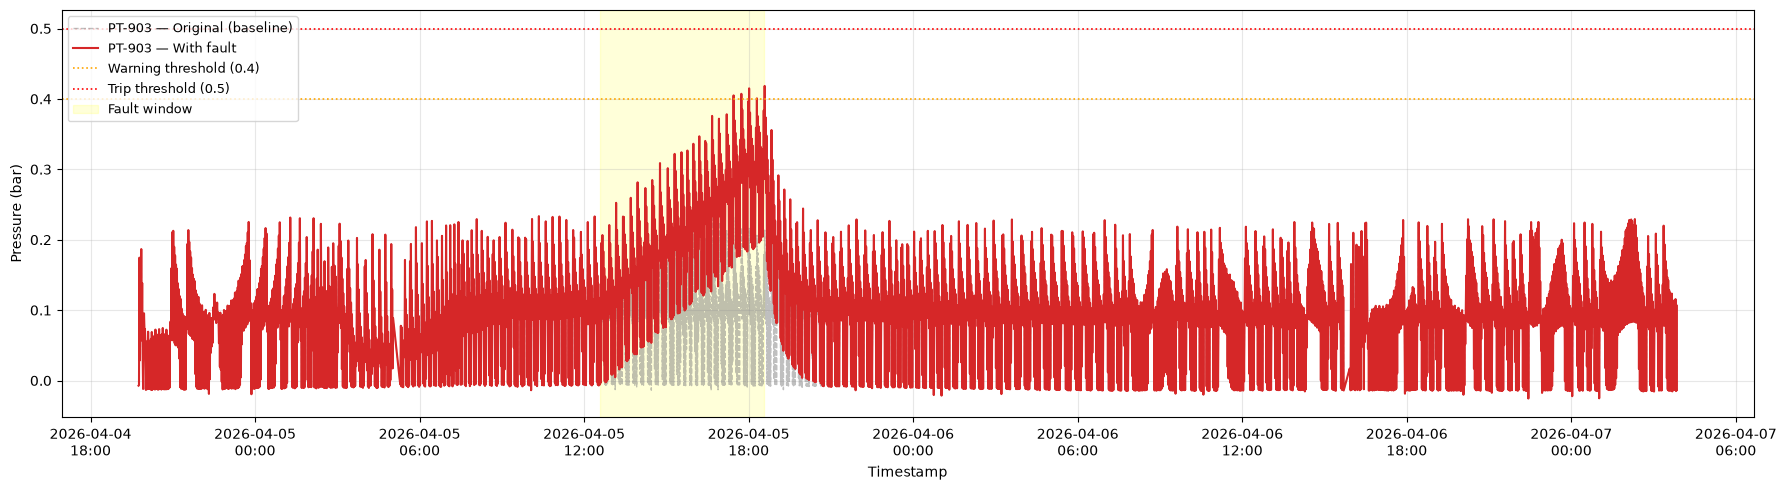

  wrote ../imgs/fault_f1_medium_s16.png


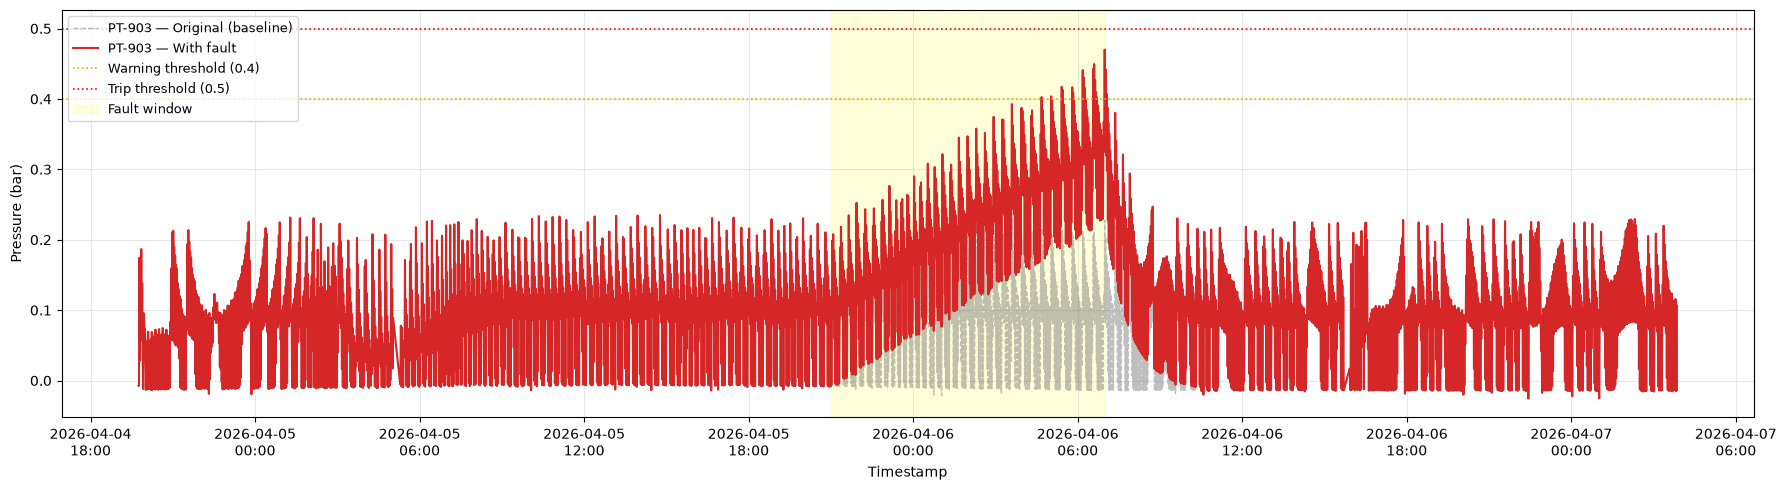

  wrote ../imgs/fault_f1_severe_s16.png


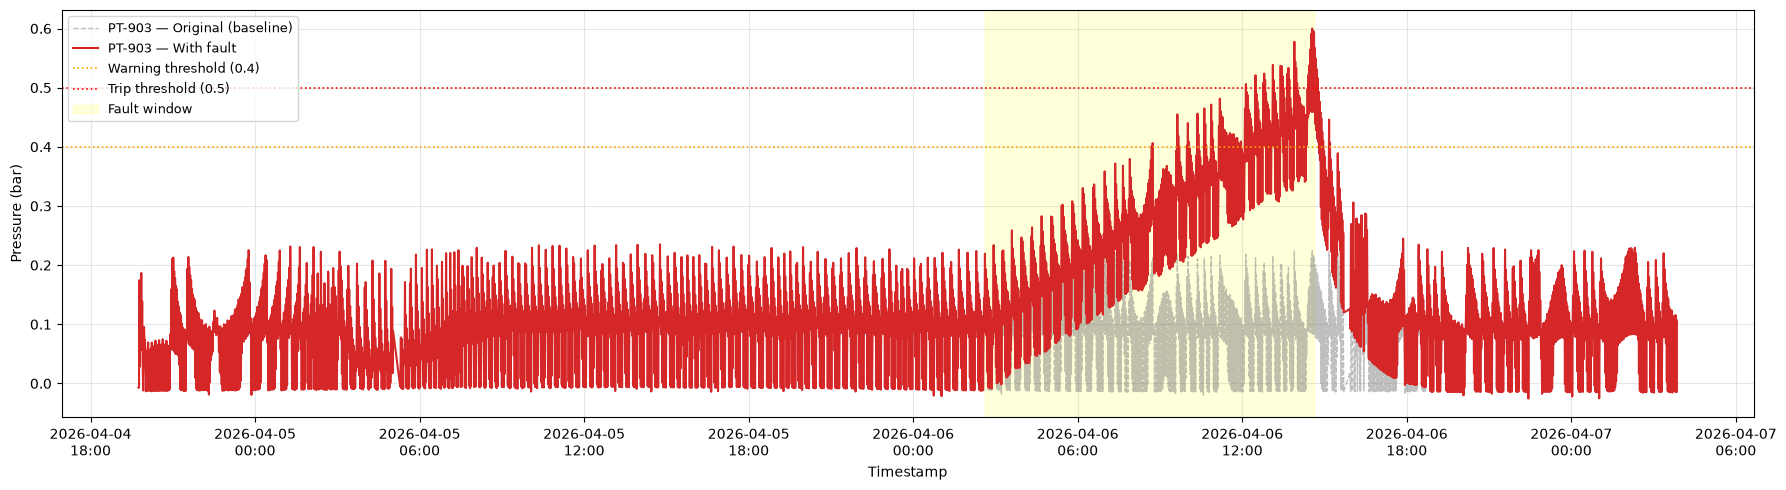

  wrote ../imgs/fault_f2_small_s16.png


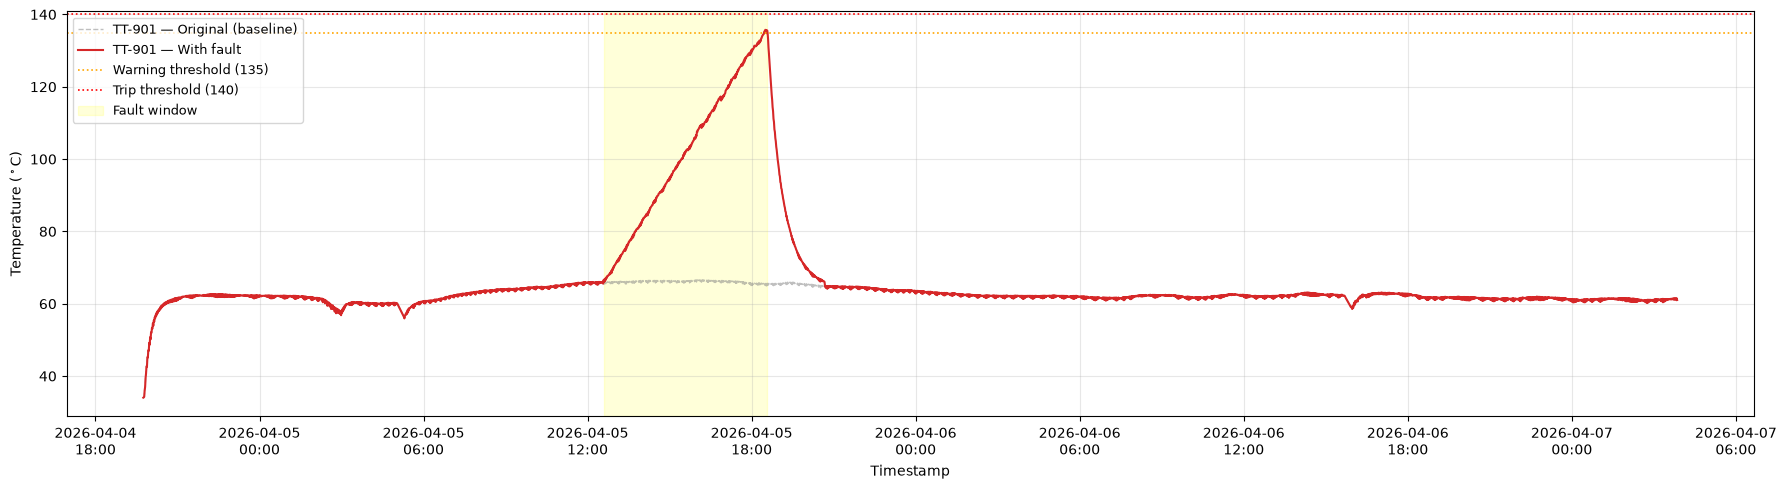

  wrote ../imgs/fault_f2_medium_s16.png


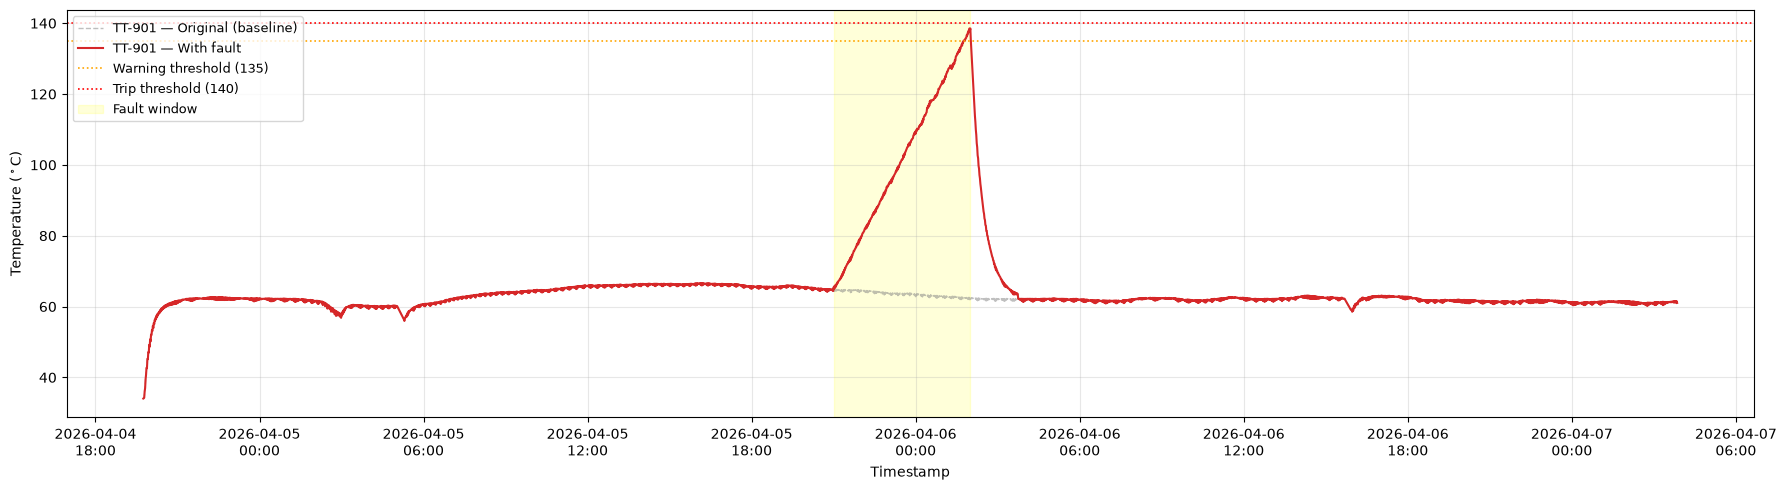

  wrote ../imgs/fault_f2_severe_s16.png


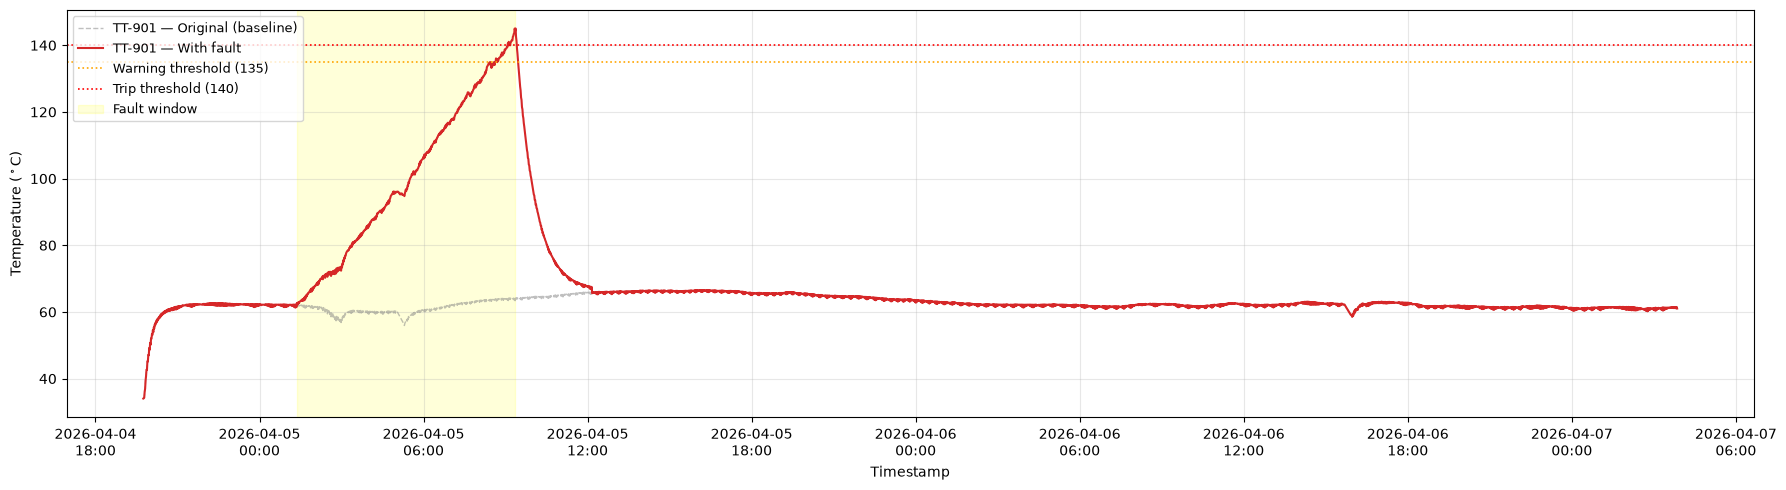

  wrote ../imgs/fault_f3_small_s16.png


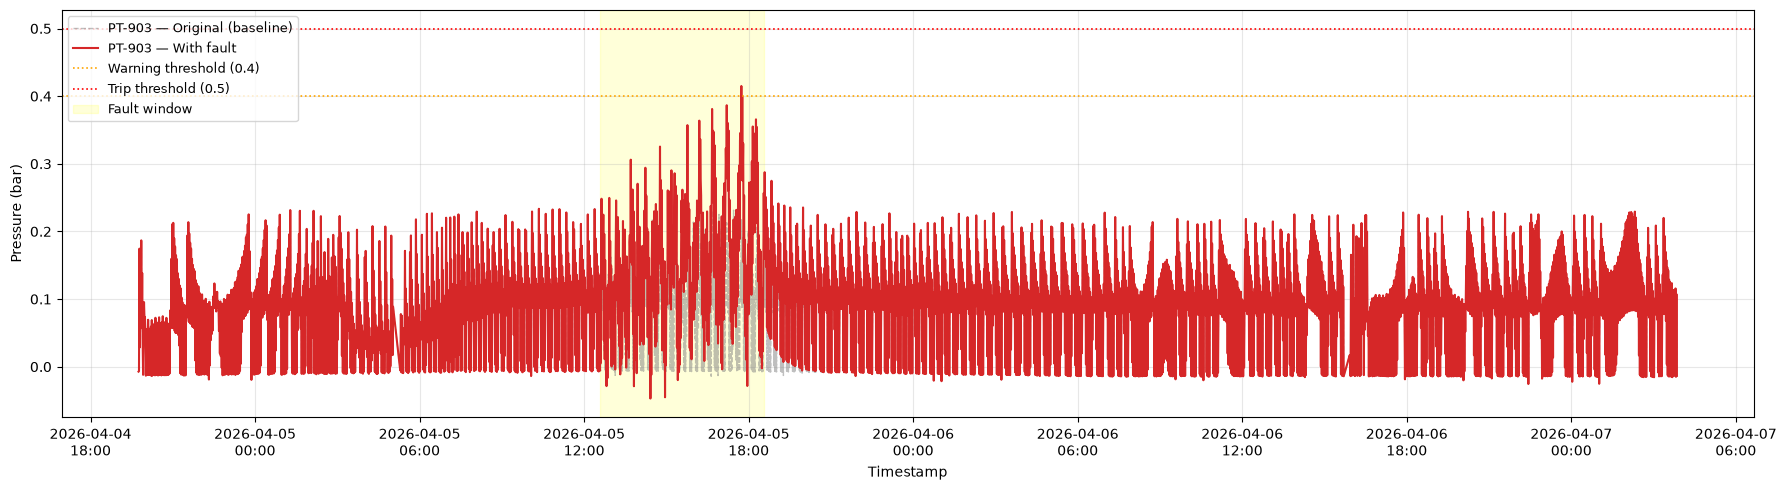

  wrote ../imgs/fault_f3_medium_s16.png


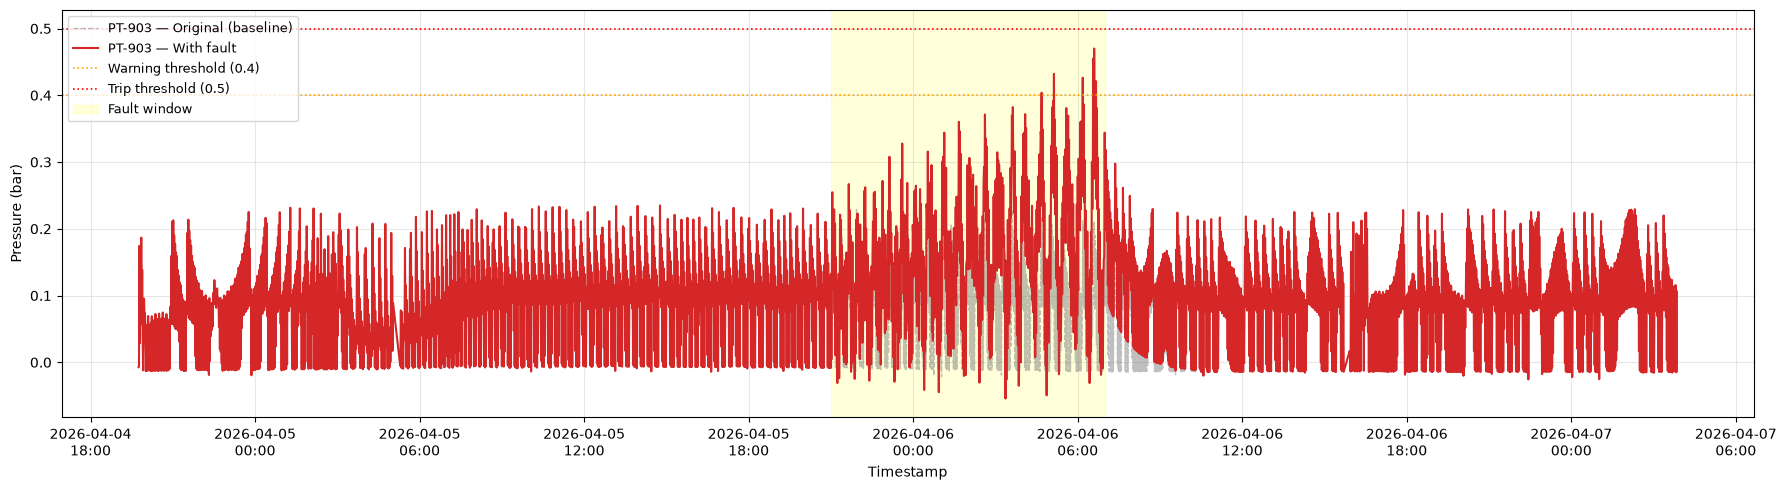

  wrote ../imgs/fault_f3_severe_s16.png


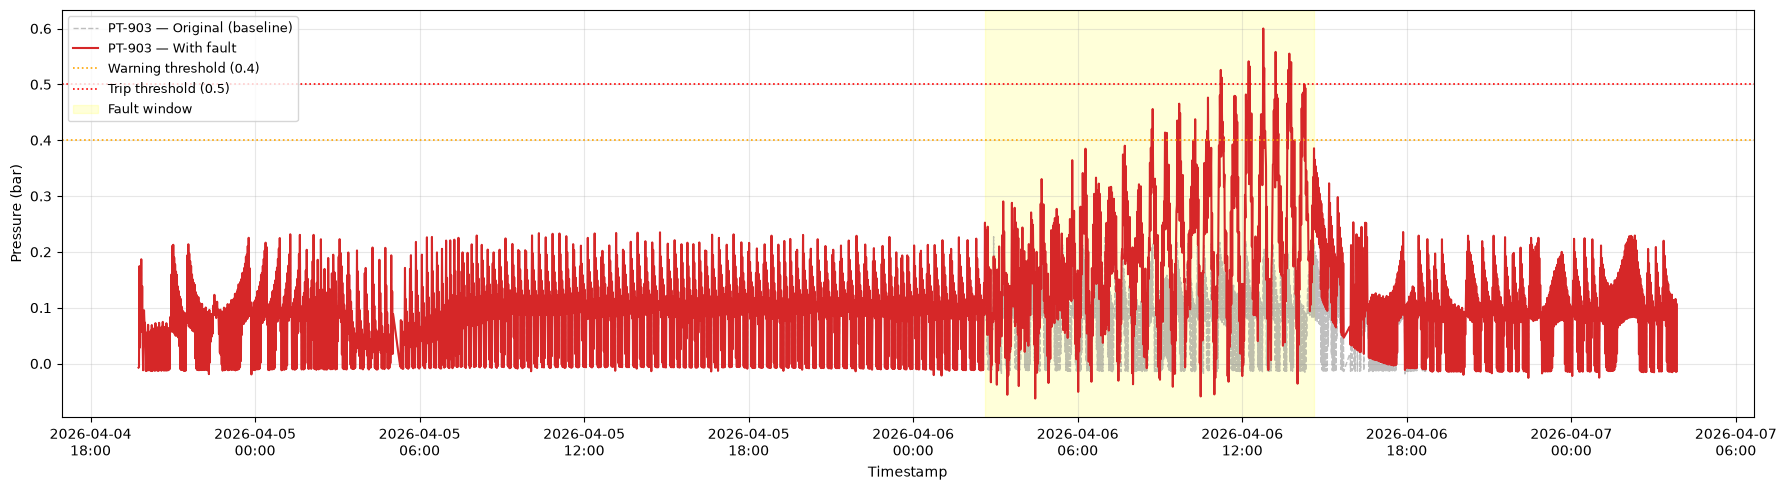

  wrote ../imgs/fault_f4_small_s16.png


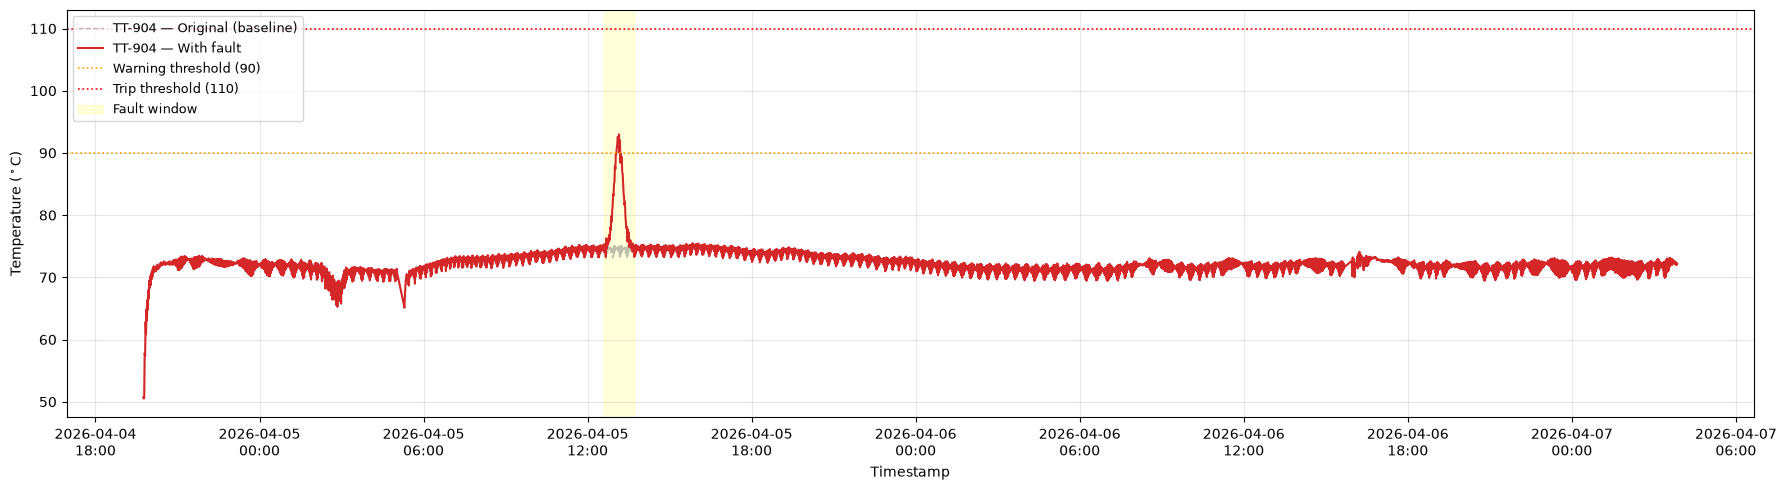

  wrote ../imgs/fault_f4_medium_s16.png


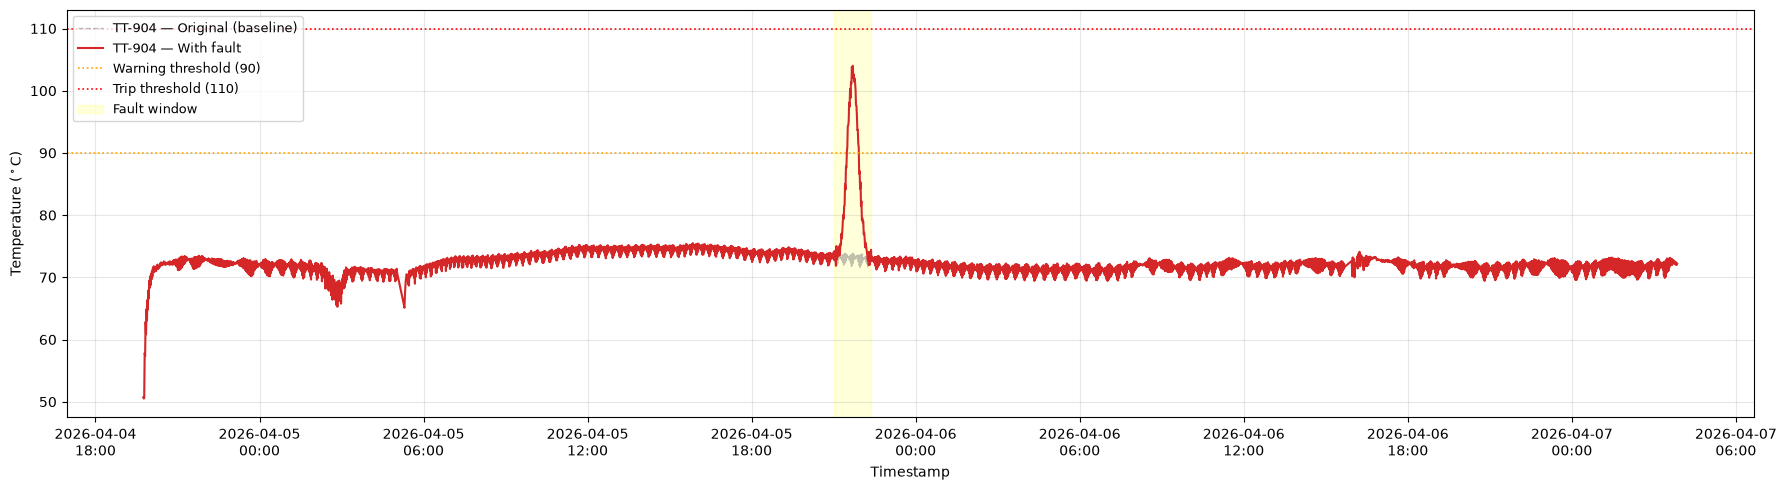

  wrote ../imgs/fault_f4_severe_s16.png


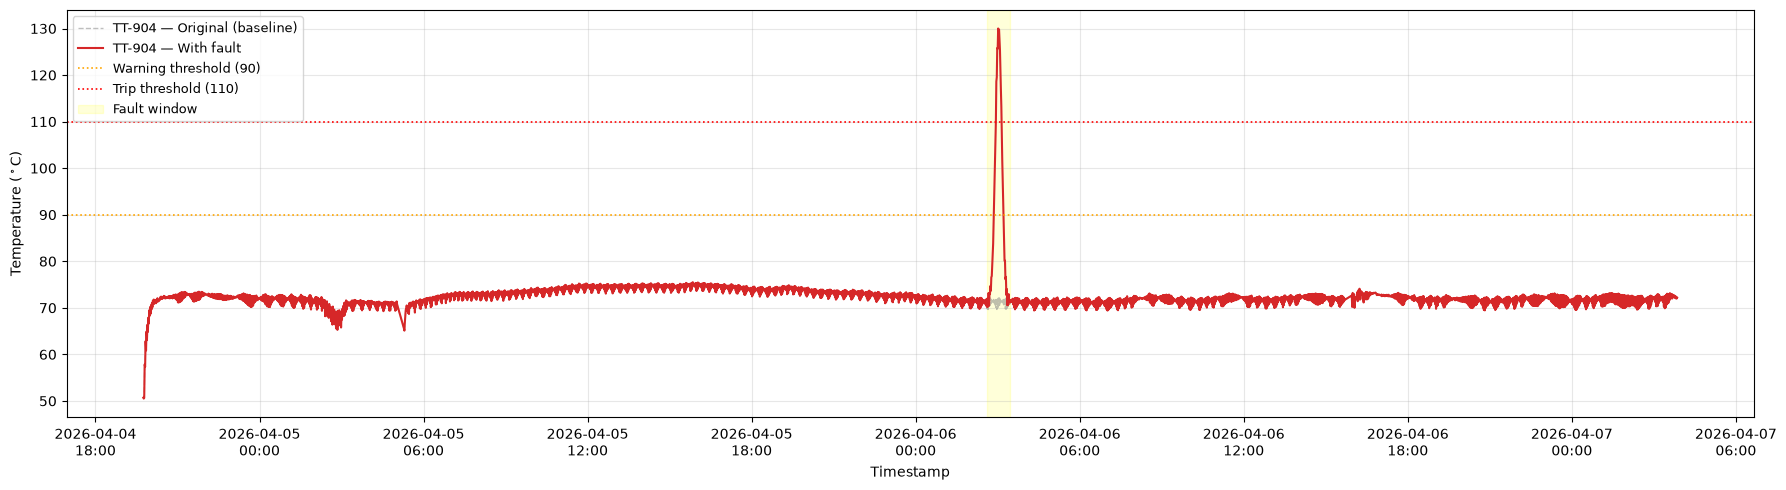

  wrote ../imgs/fault_f1_small_s17.png


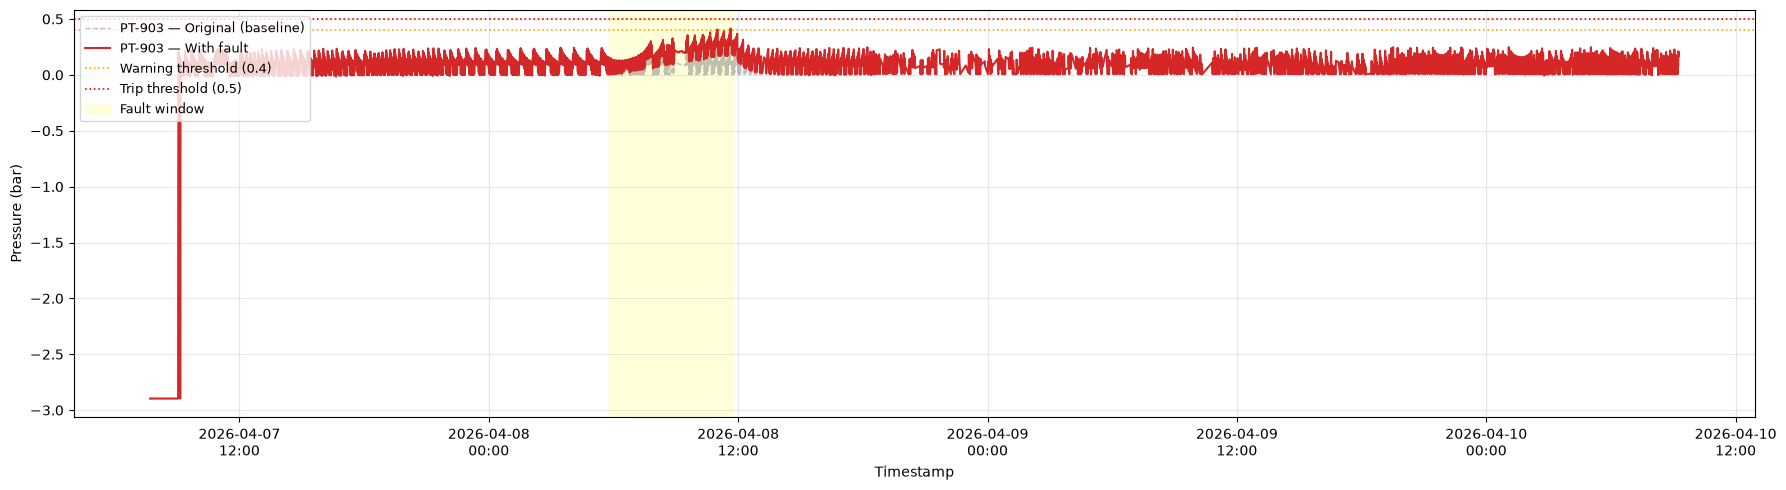

  wrote ../imgs/fault_f1_medium_s17.png


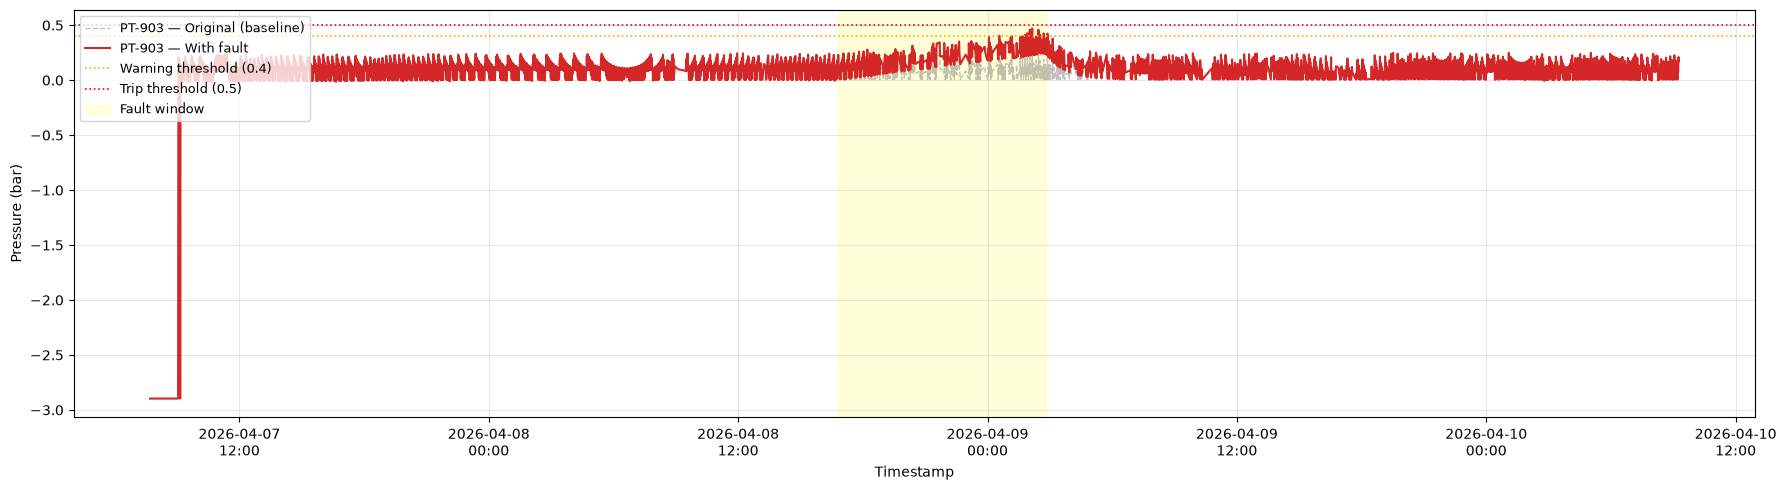

  wrote ../imgs/fault_f1_severe_s17.png


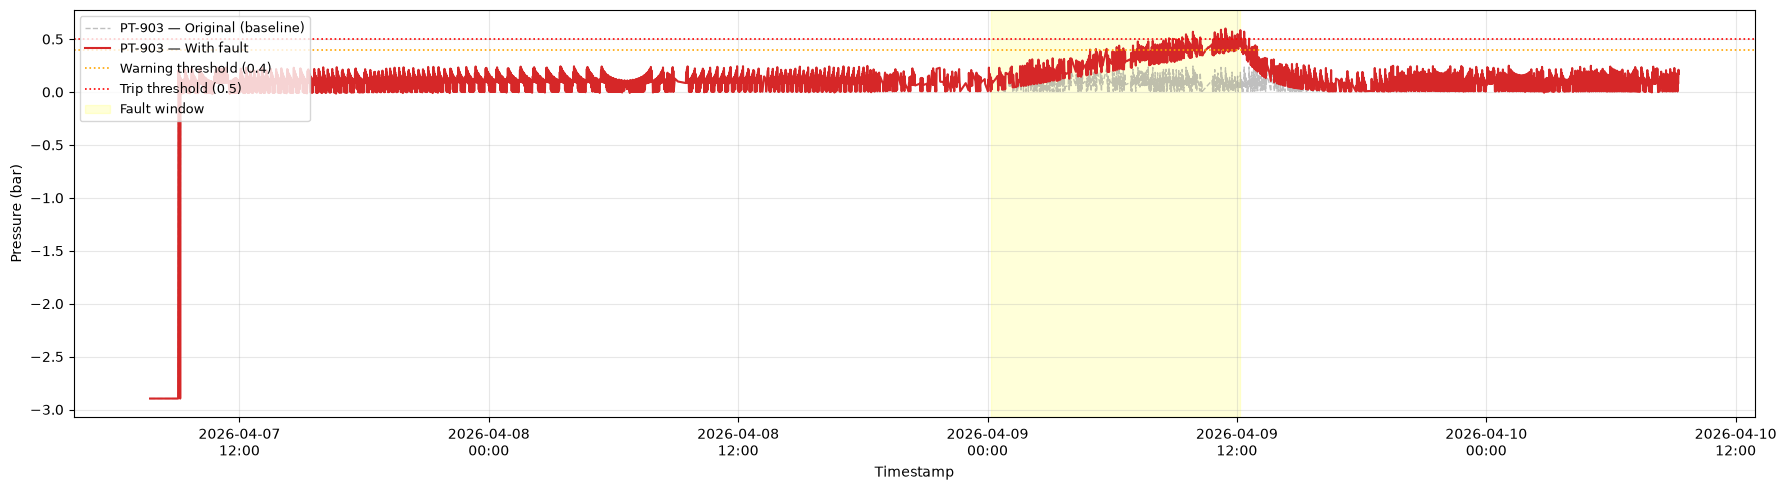

  wrote ../imgs/fault_f2_small_s17.png


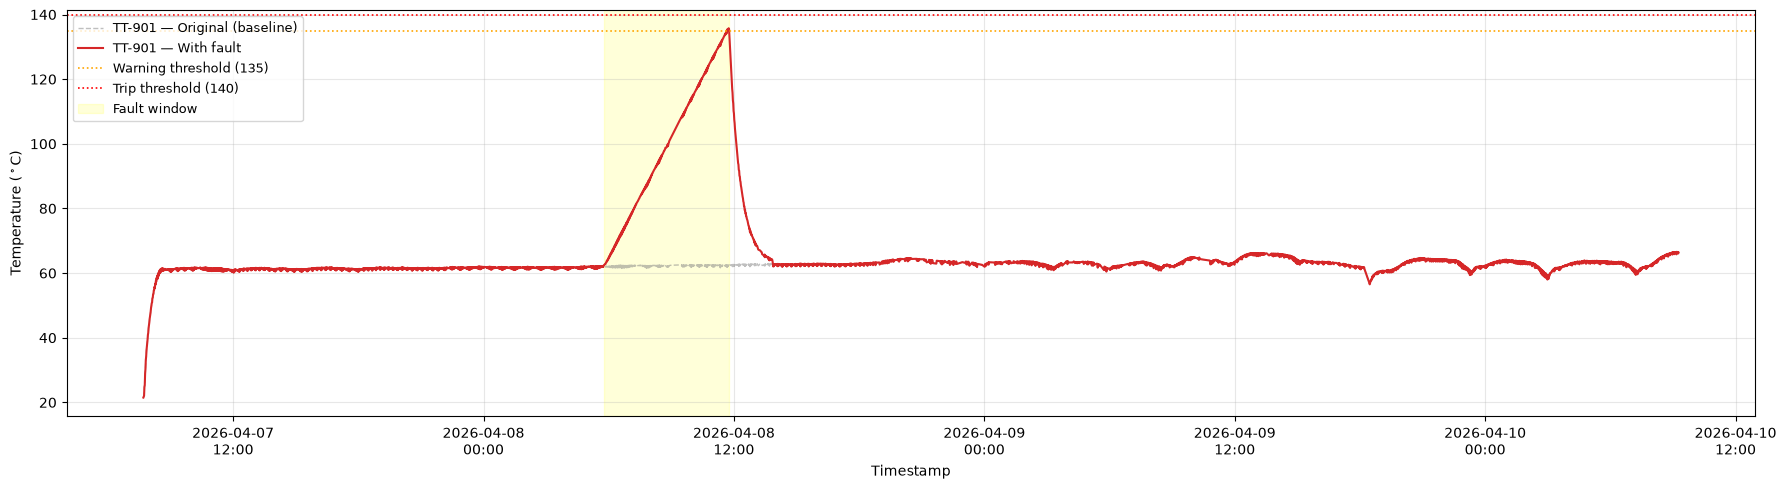

  wrote ../imgs/fault_f2_medium_s17.png


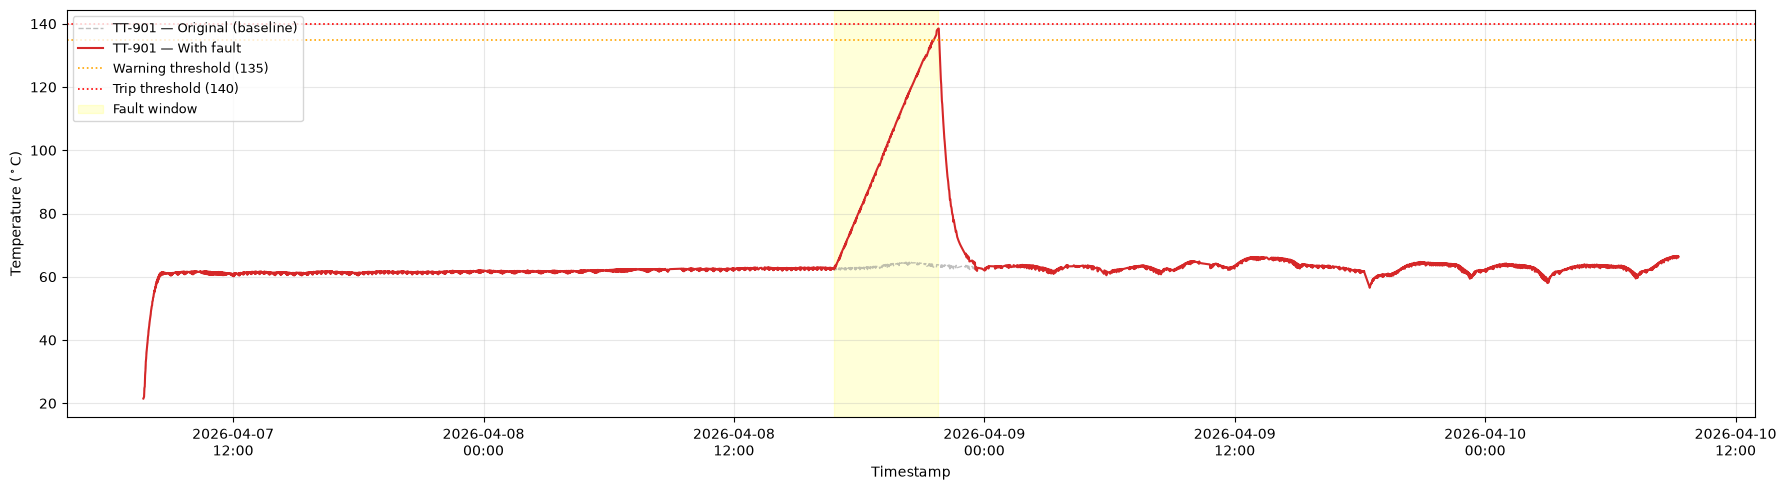

  wrote ../imgs/fault_f2_severe_s17.png


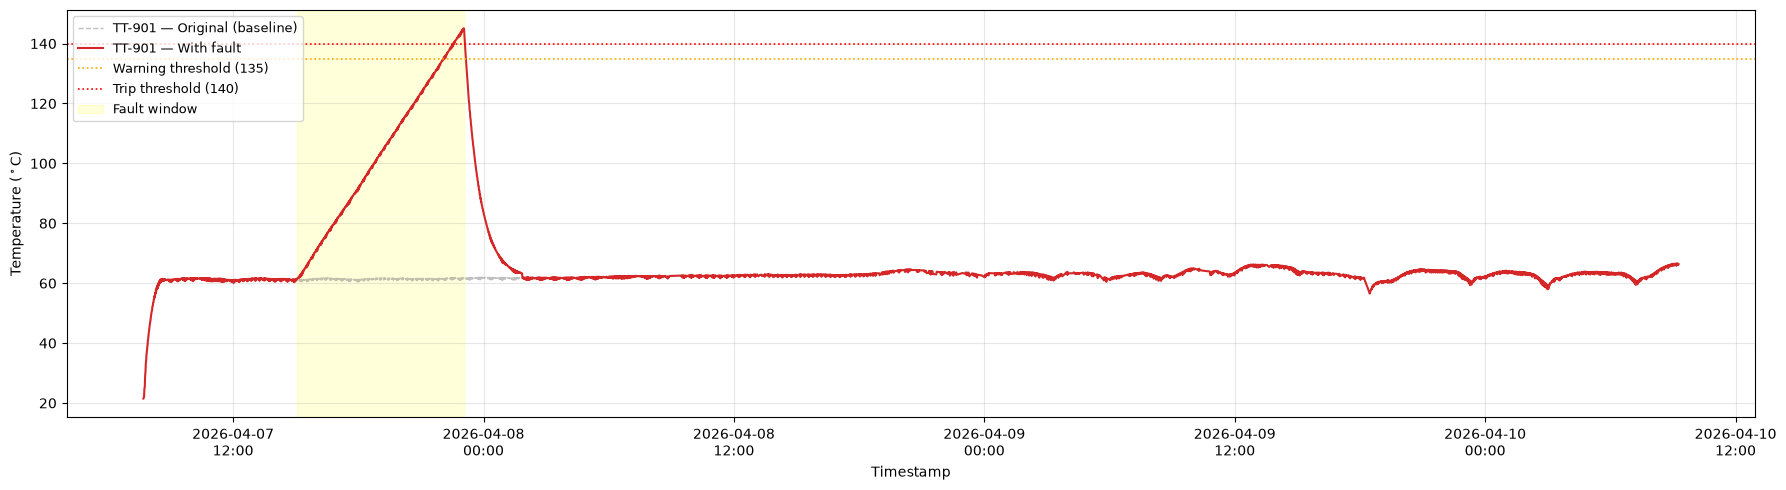

  wrote ../imgs/fault_f3_small_s17.png


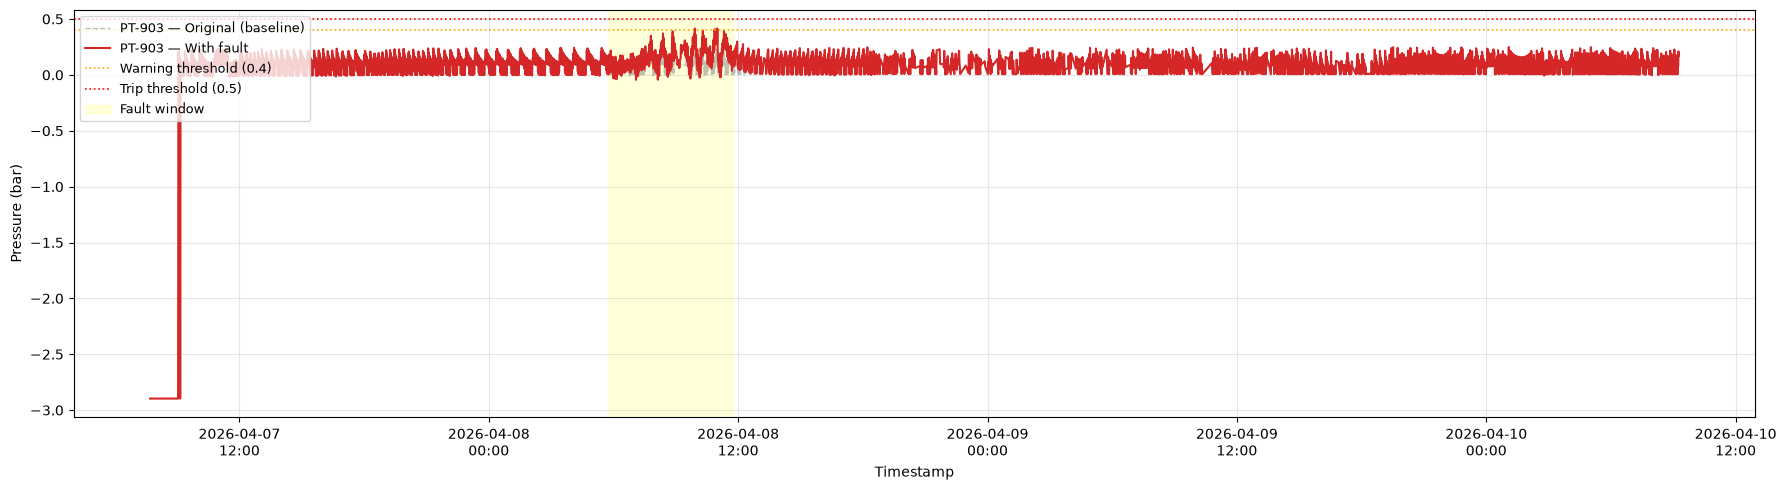

  wrote ../imgs/fault_f3_medium_s17.png


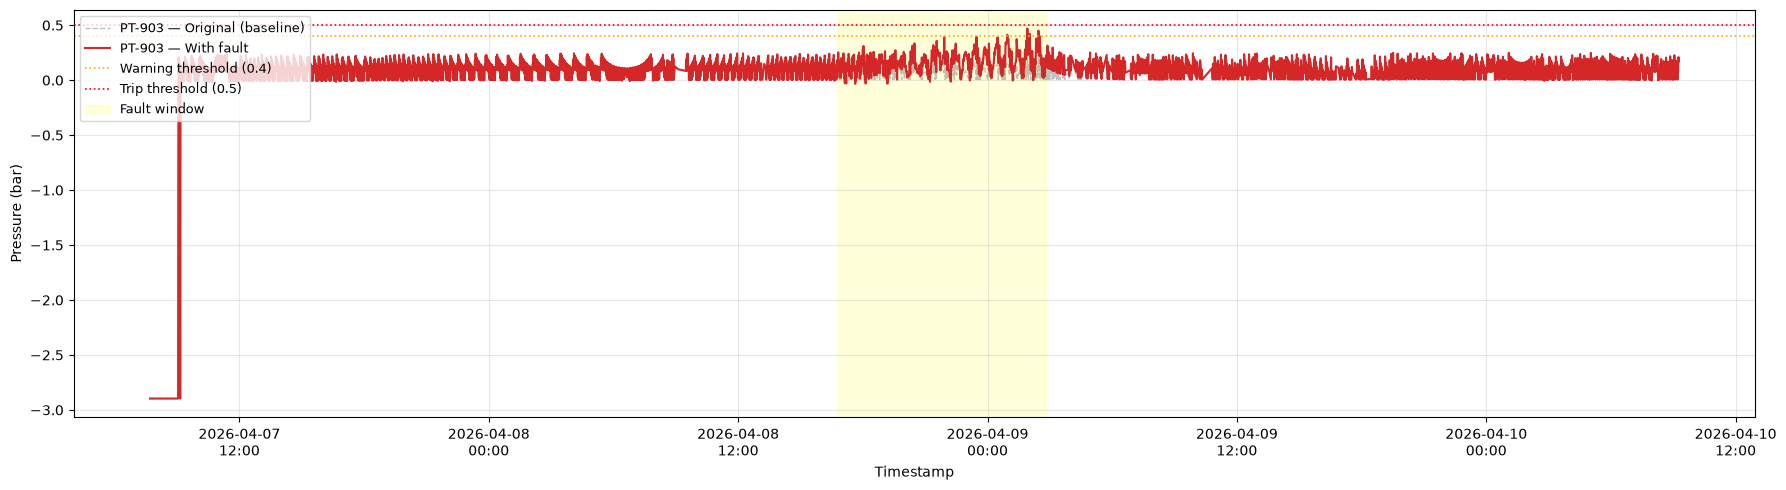

  wrote ../imgs/fault_f3_severe_s17.png


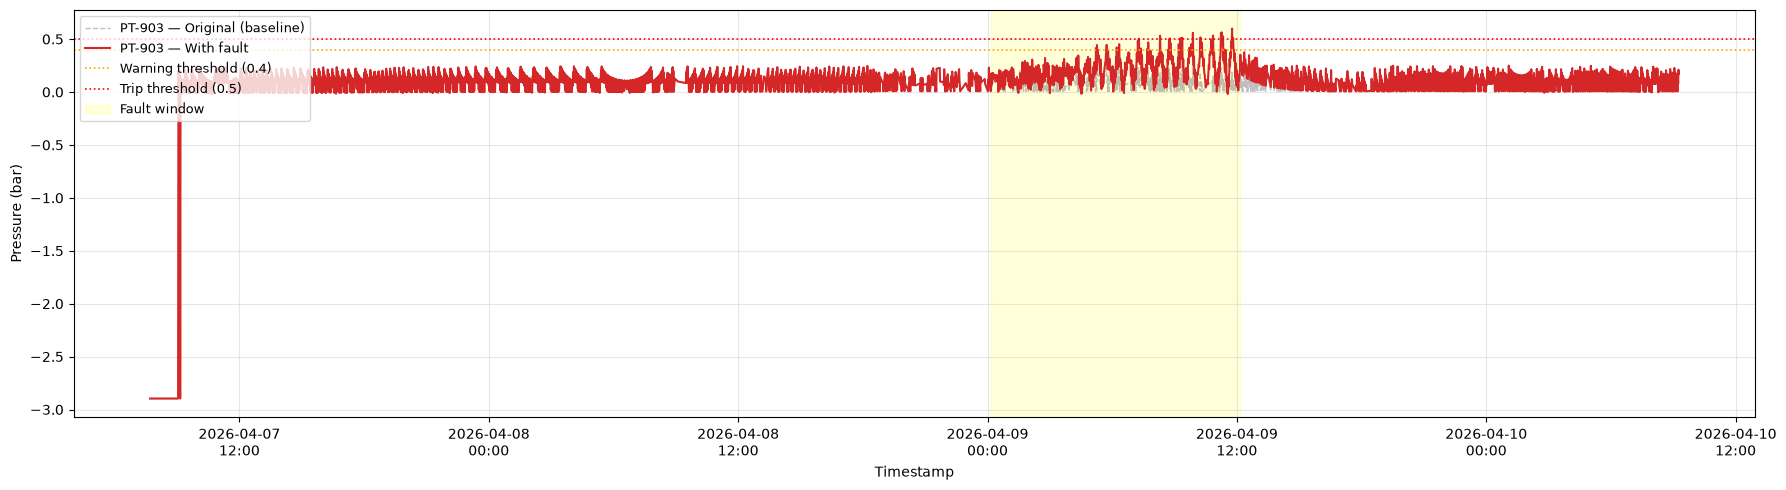

  wrote ../imgs/fault_f4_small_s17.png


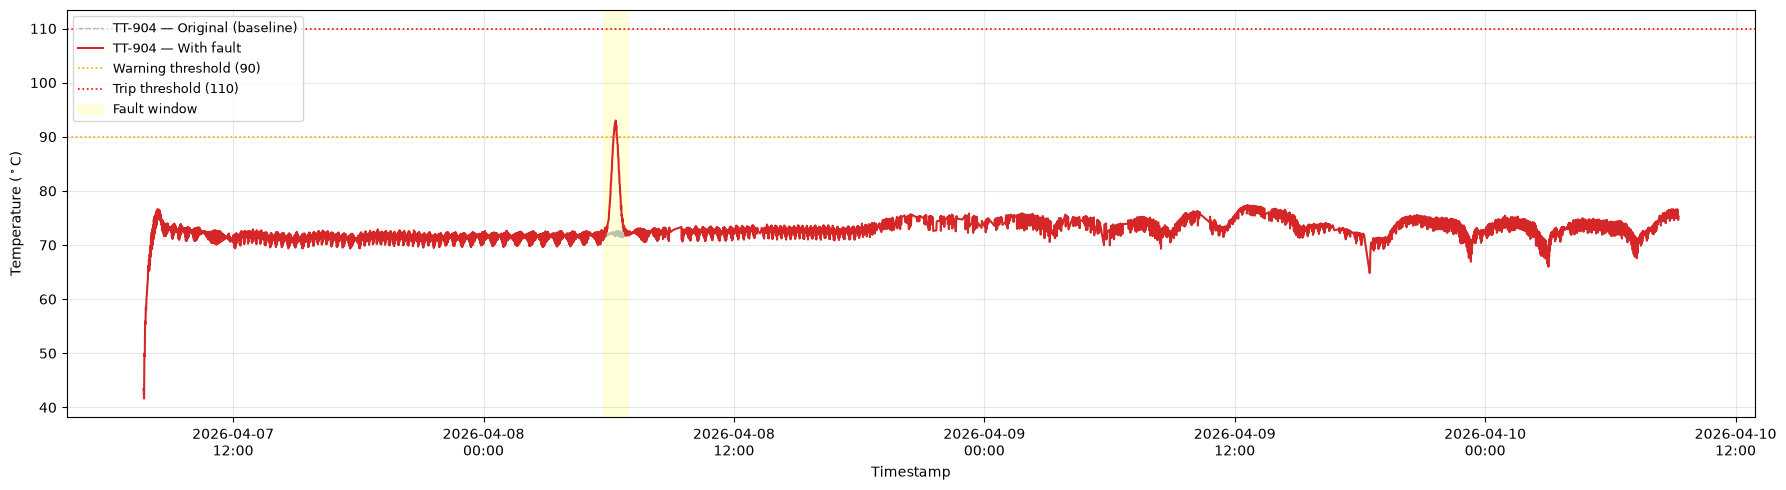

  wrote ../imgs/fault_f4_medium_s17.png


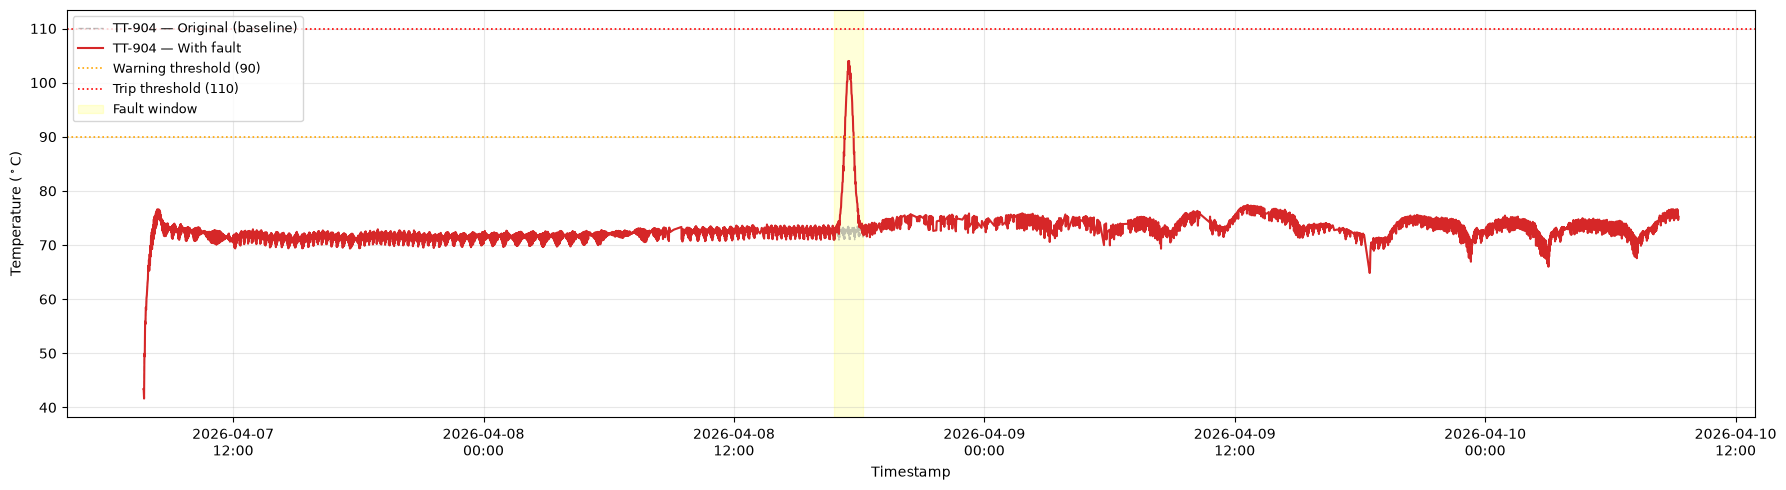

  wrote ../imgs/fault_f4_severe_s17.png


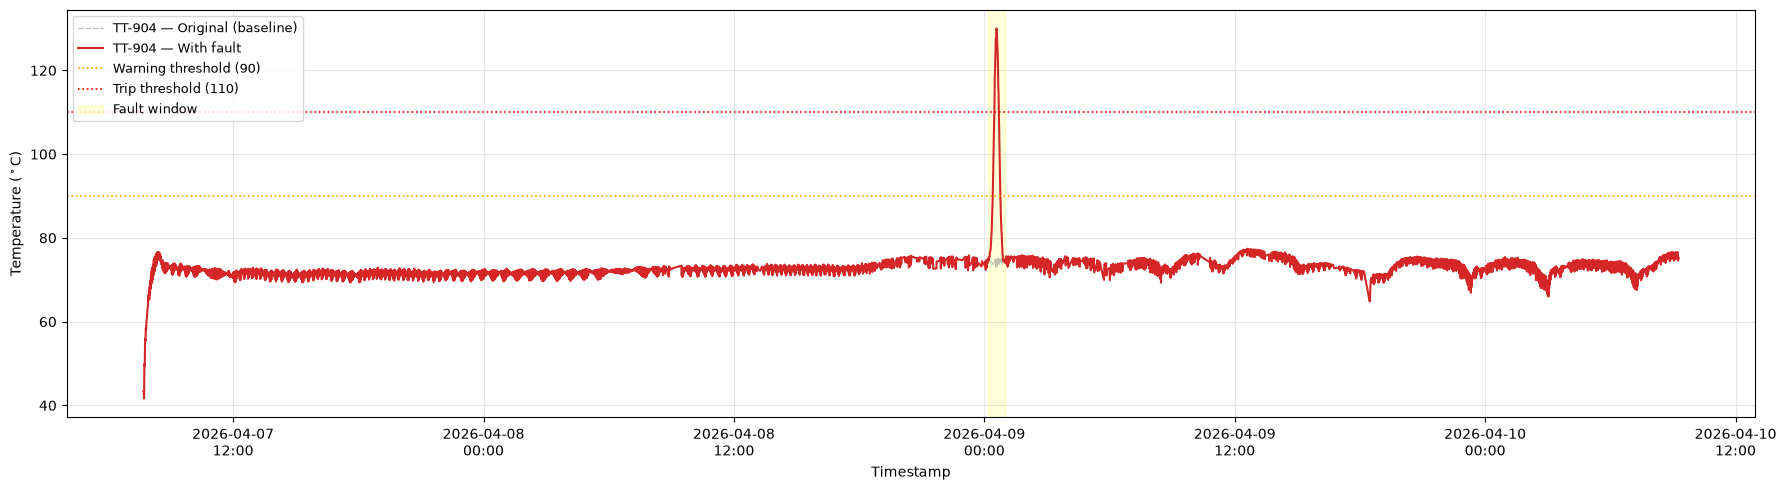


Combined fault scenarios
  wrote ../imgs/fault_combo_a_s16.png


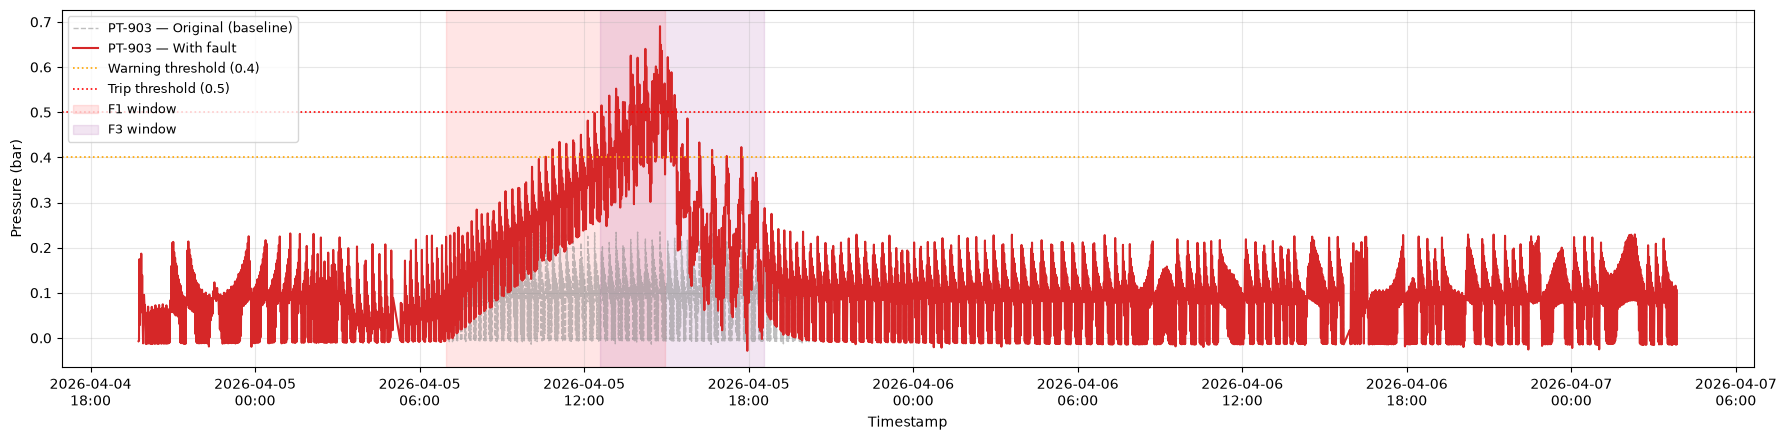

  wrote ../imgs/fault_combo_b_s16.png


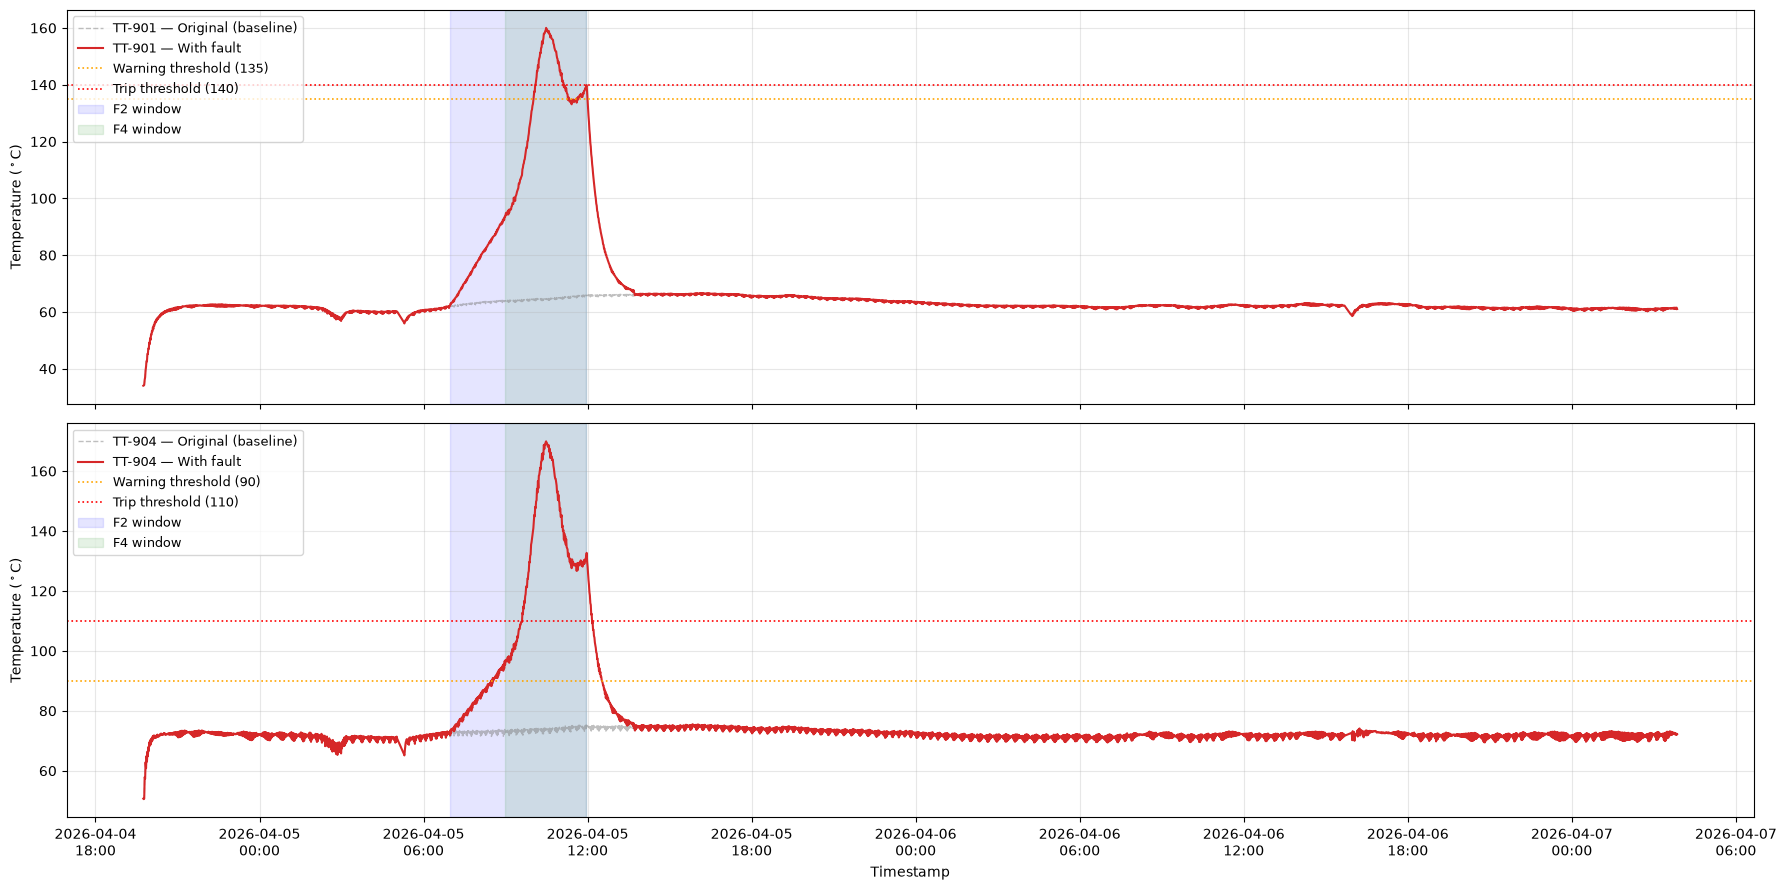

  wrote ../imgs/fault_combo_a_s17.png


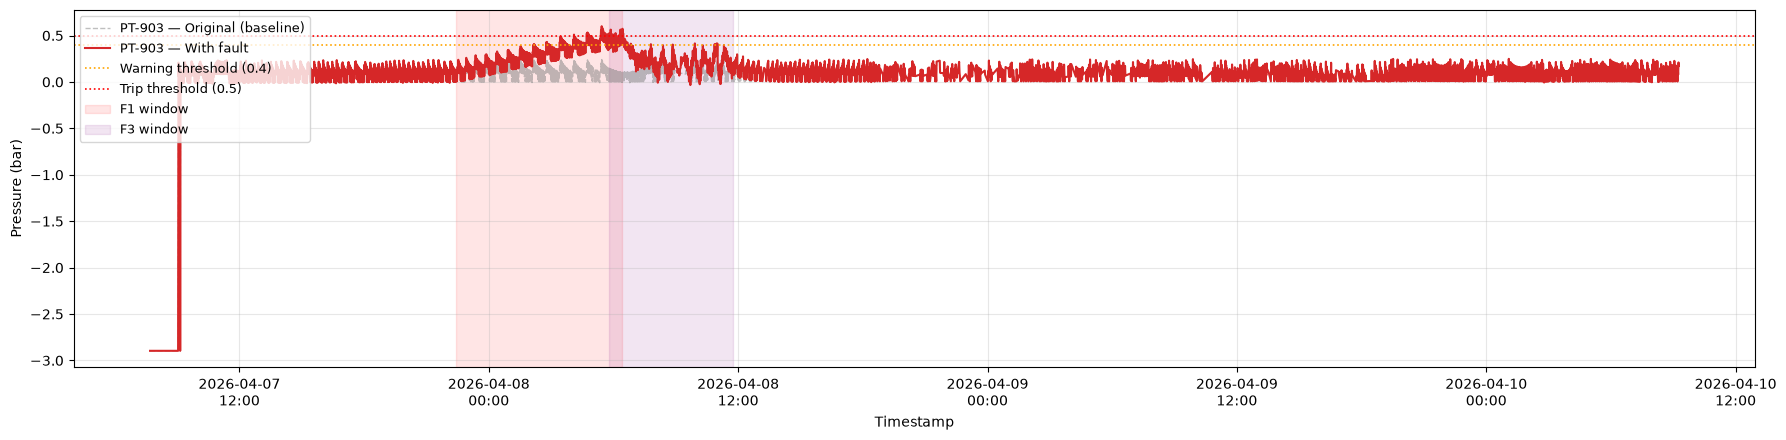

  wrote ../imgs/fault_combo_b_s17.png


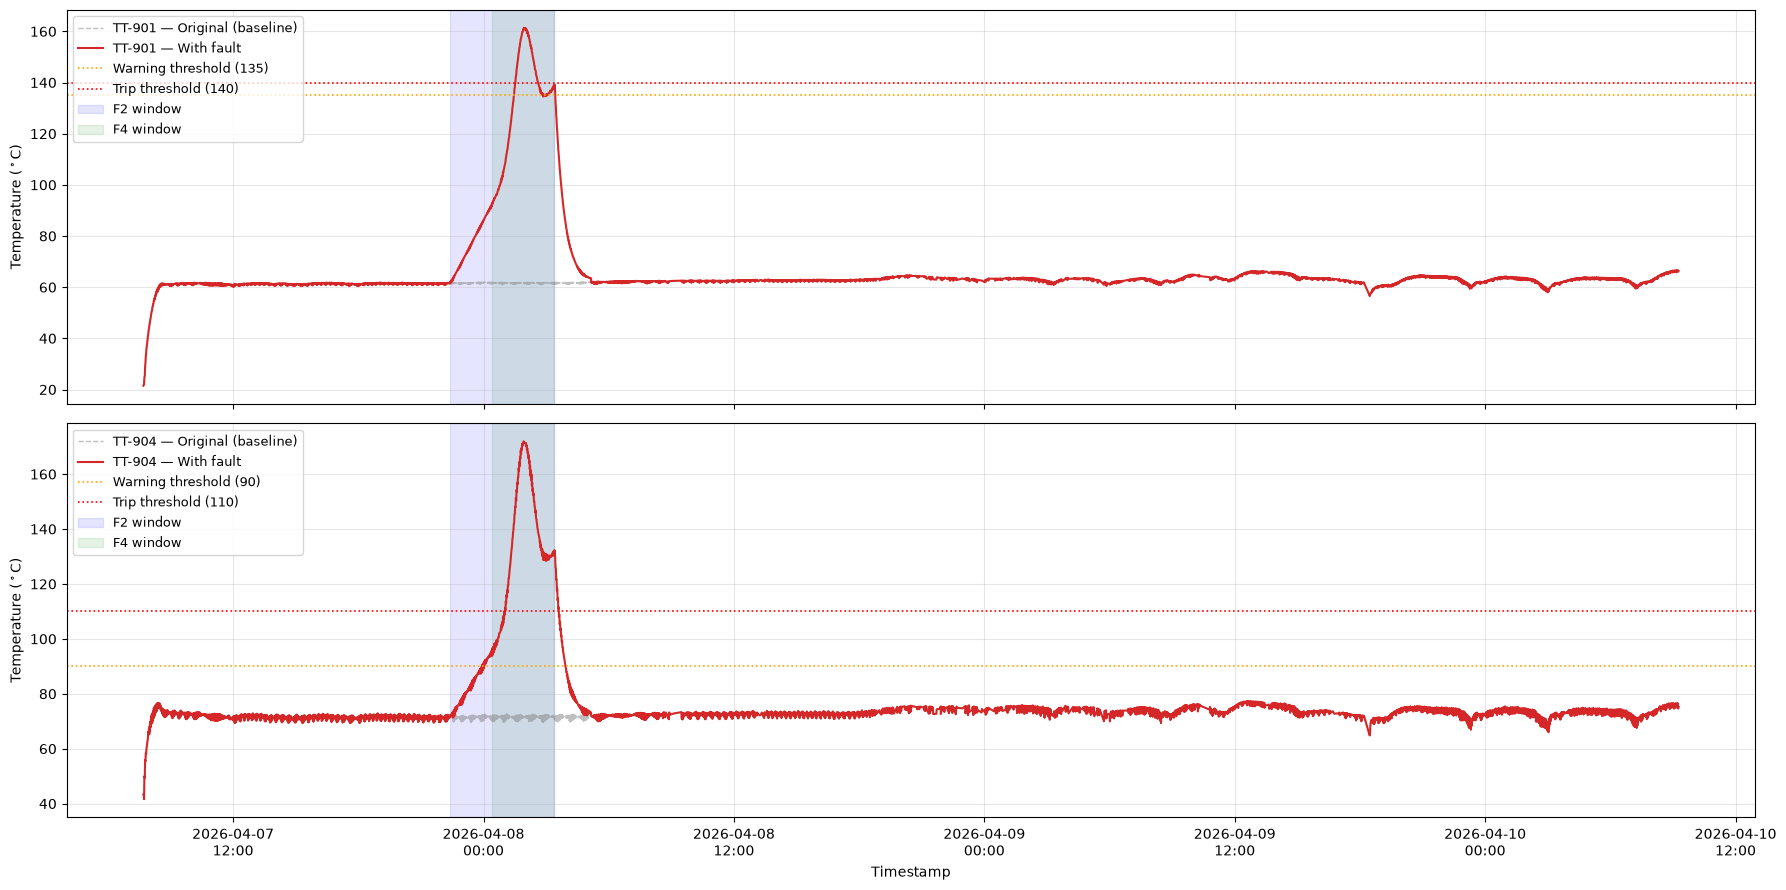


False positive scenarios
  wrote ../imgs/fault_fp_s16.png


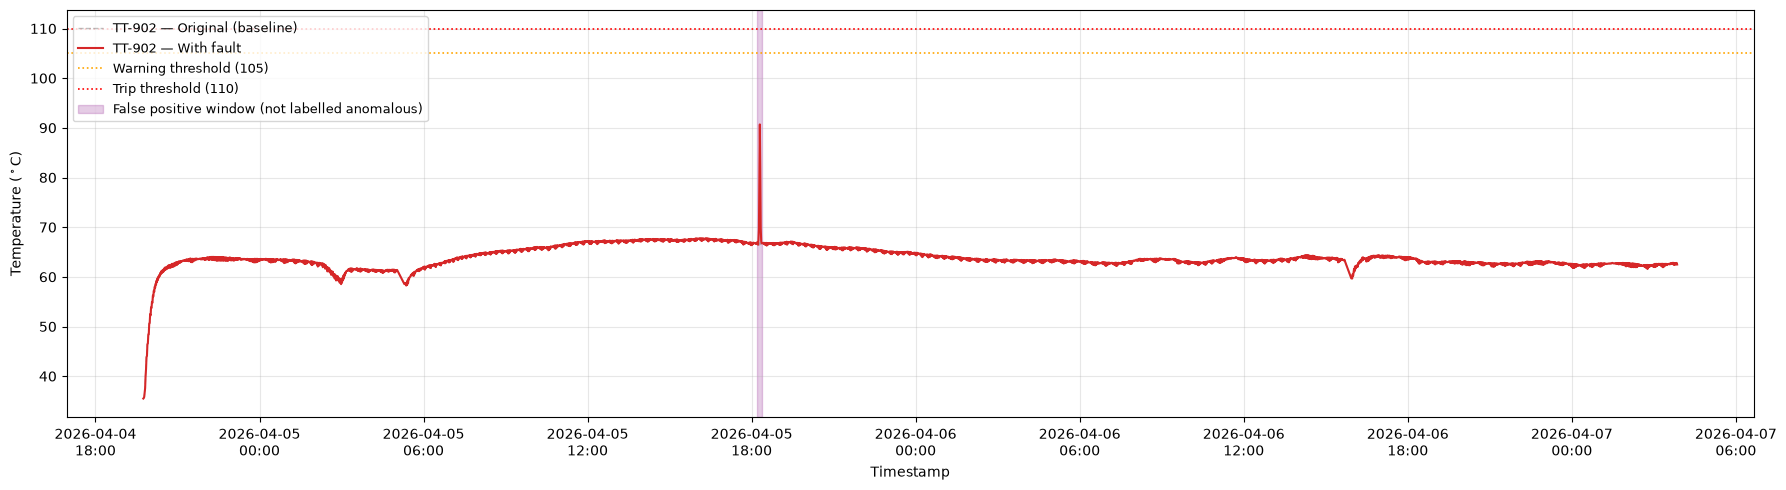

  wrote ../imgs/fault_fp_s17.png


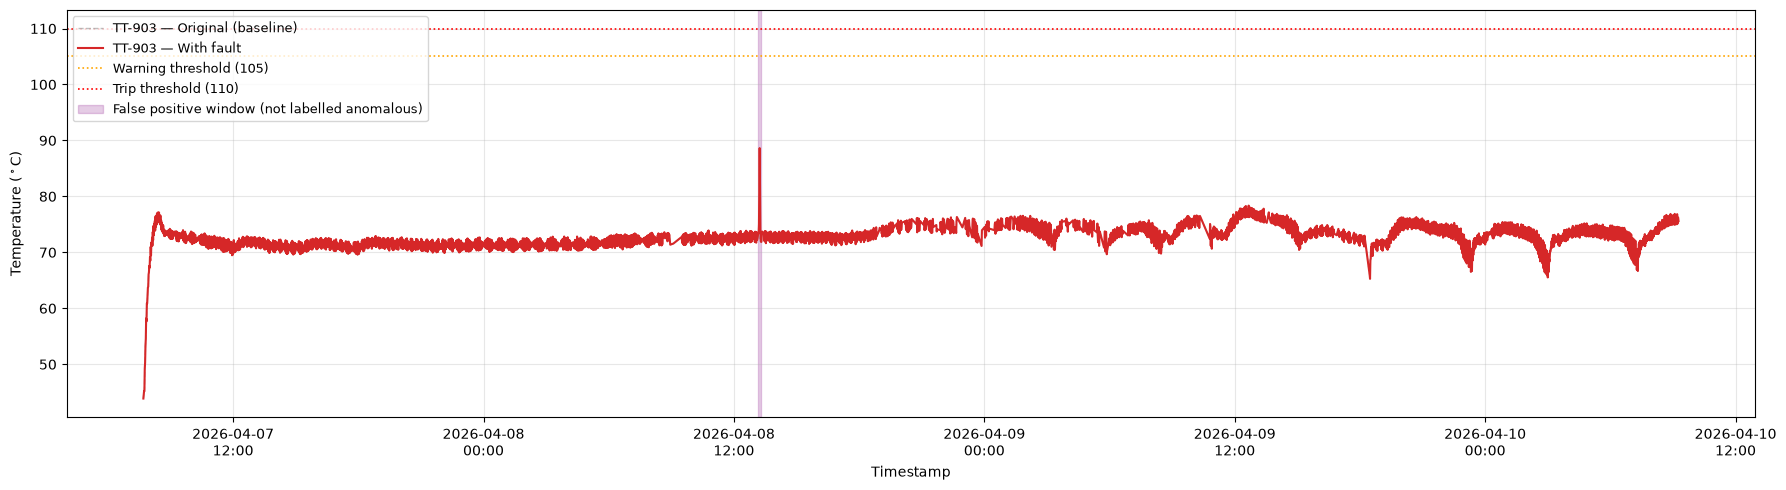


Done — 30 figures written to ../imgs/


In [8]:
""" ============================================================
    FAULT INJECTION — VERIFICATION PLOTS
    Generates every figure used in Chapter 4 and in Appendix B:
    all single faults, both combined scenarios and both false
    positive scenarios, for every session.
    ============================================================ """

import os

IMG_DIR    = "../imgs"
SHOW_PLOTS = True          # set to False to write the files without rendering them
os.makedirs(IMG_DIR, exist_ok=True)

YLABELS = {
    "PT-903": "Pressure (bar)",
    "TT-901": r"Temperature ($^\circ$C)",
    "TT-902": r"Temperature ($^\circ$C)",
    "TT-903": r"Temperature ($^\circ$C)",
    "TT-904": r"Temperature ($^\circ$C)",
}
WINDOW_COLORS = {"F1": "red", "F2": "blue", "F3": "purple", "F4": "green"}

# false positive injection parameters, mirroring the call made above
FP_START_FROM   = 0.40
FP_DURATION_MIN = 12


def _finish(fig, ax_list, save_name):
    for ax in ax_list:
        ax.legend(loc="upper left", fontsize=9)
        ax.grid(True, alpha=0.3)
    ax_list[-1].set_xlabel("Timestamp")
    ax_list[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
    fig.tight_layout()
    path = os.path.join(IMG_DIR, save_name)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"  wrote {path}")
    plt.show() if SHOW_PLOTS else plt.close(fig)


def _draw_signal(ax, df_orig, df_fault, sensor, warning, trip):
    ax.plot(df_orig.index, df_orig[sensor], color="gray", alpha=0.5, linestyle="--",
            linewidth=1.0, label=f"{sensor} — Original (baseline)")
    ax.plot(df_fault.index, df_fault[sensor], color="#d62728", linewidth=1.5,
            label=f"{sensor} — With fault")
    ax.axhline(y=warning, color="orange", linestyle=":", linewidth=1.2,
               label=f"Warning threshold ({warning})")
    ax.axhline(y=trip, color="red", linestyle=":", linewidth=1.2,
               label=f"Trip threshold ({trip})")
    ax.set_ylabel(YLABELS[sensor])


def plot_single_fault(df_orig, df_fault, sensor, warning, trip, start_idx, end_idx, save_name):
    fig, ax = plt.subplots(1, 1, figsize=(18, 5))
    _draw_signal(ax, df_orig, df_fault, sensor, warning, trip)
    ax.axvspan(df_fault.index[start_idx], df_fault.index[end_idx - 1],
               color="yellow", alpha=0.15, label="Fault window")
    _finish(fig, [ax], save_name)


def plot_combined_fault(df_orig, df_combo, panels, windows, save_name):
    """One panel per main sensor involved. Every component window is shaded in
    all panels, so the timing relationship between the two faults stays visible
    even in the panel whose own sensor is not affected by that component."""
    fig, axes = plt.subplots(len(panels), 1, figsize=(18, 4.5 * len(panels)), sharex=True)
    axes = np.atleast_1d(axes)

    for ax, sensor in zip(axes, panels):
        warning, trip = THRESHOLDS[sensor]
        _draw_signal(ax, df_orig, df_combo, sensor, warning, trip)
        for fault_id, (s, e) in windows.items():
            ax.axvspan(df_combo.index[s], df_combo.index[e - 1],
                       color=WINDOW_COLORS[fault_id], alpha=0.10,
                       label=f"{fault_id} window")
    _finish(fig, list(axes), save_name)


def plot_false_positive(df_orig, df_fp, sensor, warning, trip, start_idx, end_idx, save_name):
    """The spike is deliberately kept below the trip threshold and is never
    labelled as an anomaly, so the shading uses a distinct colour from the
    fault window shading used in the other figures."""
    fig, ax = plt.subplots(1, 1, figsize=(18, 5))
    _draw_signal(ax, df_orig, df_fp, sensor, warning, trip)
    ax.axvspan(df_fp.index[start_idx], df_fp.index[end_idx - 1],
               color="purple", alpha=0.20, label="False positive window (not labelled anomalous)")
    _finish(fig, [ax], save_name)


# ------------------------------------------------------------
# SINGLE FAULTS — every session, fault and severity
# ------------------------------------------------------------
print("Single fault scenarios")
for session_id in dict_sessions:
    for fault_id, cfg in FAULT_CONFIGS.items():
        warning, trip = THRESHOLDS[cfg["sensor"]]
        for severity in ["small", "medium", "severe"]:
            df_out, start_idx, end_idx = single_fault_results[(session_id, fault_id, severity)]
            plot_single_fault(
                dict_sessions[session_id], df_out, cfg["sensor"], warning, trip,
                start_idx, end_idx,
                f"fault_{fault_id.lower()}_{severity}_s{session_id}.png",
            )

# ------------------------------------------------------------
# COMBINED FAULTS — Combo A on one sensor, Combo B on two
# ------------------------------------------------------------
print("\nCombined fault scenarios")
COMBO_PANELS = {"combo_A": ["PT-903"], "combo_B": ["TT-901", "TT-904"]}

for session_id in dict_sessions:
    for combo, panels in COMBO_PANELS.items():
        df_combo, windows = combined_fault_results[(session_id, combo)]
        plot_combined_fault(
            dict_sessions[session_id], df_combo, panels, windows,
            f"fault_{combo.lower()}_s{session_id}.png",
        )

# ------------------------------------------------------------
# FALSE POSITIVES — reloaded from disk, window recomputed from the
# same parameters used at injection time
# ------------------------------------------------------------
print("\nFalse positive scenarios")
for session_id, df_session in dict_sessions.items():
    sensor = FP_SENSOR_PER_SESSION.get(session_id, "TT-902")
    warning, trip = THRESHOLDS[sensor]

    path = f"{output_dir_fp}/session_{session_id}_fp_standalone_{sensor.replace('-','')}.csv"
    df_fp = pd.read_csv(path, index_col=0, parse_dates=True)

    start_idx = int(round(len(df_session) * FP_START_FROM))
    end_idx   = min(start_idx + FP_DURATION_MIN, len(df_session))

    plot_false_positive(dict_sessions[session_id], df_fp, sensor, warning, trip,
                        start_idx, end_idx, f"fault_fp_s{session_id}.png")

print(f"\nDone — 30 figures written to {IMG_DIR}/")